In [2]:
# Read in the anndata object
import anndata as ad
from pathlib import Path
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from scipy.stats import spearmanr, pearsonr
import scipy.sparse as sp
from scipy.cluster.hierarchy import linkage, dendrogram
from matplotlib.ticker import ScalarFormatter
import scanpy as sc
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
from sklearn.metrics import r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from collections import defaultdict
import warnings
from adjustText import adjust_text

warnings.filterwarnings('ignore')

# Import LeafletFA differential splicing code
# Define module paths
src_path = "/gpfs/commons/home/kisaev/Leaflet-private/src/"

# Add to sys.path if not already present
if src_path not in sys.path:
    sys.path.append(src_path)

# Import custom modules
import BetaDirichletFactor.differential_splicing as ds

In [3]:
# Import utility functions - simple direct import
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from utils import *
from figure_plotting import * 

In [4]:
# Import all functions from /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/atse_viz.py
import sys
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from atse_viz import *
import gffutils

mouse_db_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/GENCODE_vM19"
db_mouse = gffutils.FeatureDB(mouse_db_file, keep_order=True)

Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Visualization imports successful!


In [5]:
# =============================================================================
# CONFIGURATION - EDIT THESE VALUES ONLY
# =============================================================================

# Base directories
BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION"
RESULTS_BASE_DIR = "/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results"

GE_ANNDATA_scVI_PATH = f"{BASE_DIR}/scVI/ge_adata_with_both_scvi_models_2025-07-06.h5ad"
GE_ANNDATA_NMF_PATH = f"{BASE_DIR}/NMF/ge_adata_with_NMF_standard_50_1024_2025-07-07.h5ad"

# Reference files
AGING_GENES_PATH = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/27857814"
RBP_FILE_PATH = "/gpfs/commons/groups/knowles_lab/Karin/VanNostrand_2020_supptable1_41586_2020_2077_MOESM3_ESM.xlsx"

ATSE_FILE_PATH = (
    f"{BASE_DIR}/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-07-01_00-02-00.txt.gz"
)

# Load ATSE file
atse_df = pd.read_csv(ATSE_FILE_PATH, sep="\t")
atse_df["junction_annotation"] = "Novel_SS" 
atse_df.loc[atse_df["perfect_match_5_prime"].notna(), "junction_annotation"] = "5_prime_annotated"
atse_df.loc[atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "3_prime_annotated"
atse_df.loc[atse_df["perfect_match_5_prime"].notna() & atse_df["perfect_match_3_prime"].notna(), "junction_annotation"] = "Both_SS_annotated"

# Load splicing data
#ge_adata = ad.read_h5ad(GE_ANNDATA_scVI_PATH)
print(f"Done reading the ge_adata with scVI...")
ge_adata = ad.read_h5ad(GE_ANNDATA_NMF_PATH)
print(f"Done reading the ge_adata with NMF...")

#assert np.all(ge_adata.obs_names == ge_adata_nmf.obs_names), "Cell IDs in ge_adata and ge_adata_nmf do not match or are not in the same order."
#assert np.all(ge_adata.var_names == ge_adata_nmf.var_names), "Gene names in ge_adata and ge_adata_nmf do not match or are not in the same order."
#ge_adata.obsm["X_nmf_standard_mb"] = ge_adata_nmf.obsm["X_nmf_standard_mb"]
#ge_adata.varm["nmf_standard_mb_components"] = ge_adata_nmf.varm["nmf_standard_mb_components"]
#print(f"Done combining gene expression into one object!")

# If ge_adata.var["gene_name"] is not in ge_adata.var_names, then add it
if "gene_name" not in ge_adata.var.columns:
    ge_adata.var["gene_name"] = ge_adata.var_names

# If ge_adata.obs doesn't have cell_id make it from cell_id_clean
if "cell_id" not in ge_adata.obs.columns:
    ge_adata.obs["cell_id"] = ge_adata.obs["cell_id_clean"]
 #   ge_adata_nmf.obs["cell_id"] = ge_adata_nmf.obs["cell_id_clean"]

# Load aging gene lists
aging_genes_mouse, aging_genes_human = load_aging_genes(AGING_GENES_PATH)
    
# Load RBP genes
rbps = load_rbp_genes(RBP_FILE_PATH)
rbps["mouse_gene_name"] = rbps["mouse_gene_name"].str.upper()
aging_genes_mouse = [g.upper() for g in aging_genes_mouse]

# if "mouse.id" is in splice_adata.obs rename it to donor_id 
print(f"Renaming mouse.id to donor_id in splice_adata.obs")
# Update gene annotations
ge_adata.var["RBP_gene"] = ge_adata.var["gene_name"].isin(rbps["mouse_gene_name"])
ge_adata.var["Aging_gene"] = ge_adata.var["gene_name"].isin(aging_genes_mouse)
rbps = rbps["mouse_gene_name"]

Done reading the ge_adata with scVI...
Done reading the ge_adata with NMF...
Loaded 330 aging-related genes (mouse)
Loaded 330 aging-related genes (human)
Loaded 356 RNA binding proteins
Renaming mouse.id to donor_id in splice_adata.obs


In [6]:
# Main parameters to change
MODEL_TRAIN_DATE = "2025-07-08"
MODEL_ANALYSIS_DATE = "2025-07-10"
PARAM_ID = 0

# =============================================================================
# AUTO-GENERATED PATHS - DON'T EDIT BELOW THIS LINE
# =============================================================================

# Core result directories
PARAM_RESULTS_DIR = f"{RESULTS_BASE_DIR}/{MODEL_TRAIN_DATE}/{MODEL_ANALYSIS_DATE}/param_id_{PARAM_ID}"
DATA_DIR = f"{PARAM_RESULTS_DIR}/data"

# Model outputs
MODEL_OUTPUTS_DIR = f"{BASE_DIR}/Leaflet/leafletFAmodel/{MODEL_TRAIN_DATE}"
MODEL_PATH = f"{MODEL_OUTPUTS_DIR}/run_{PARAM_ID}/leafletfa_model.pkl.xz"

# Main data files
SPLICE_ADATA_PATH = f"{DATA_DIR}/splice_adata_PHI_psi_var_obs.h5ad"
PI_VALUES_PATH = f"{DATA_DIR}/PI_values.npy"
PERPLEXITY_PATH =  f"{DATA_DIR}/cell_metadata_with_perplexity_param_id_{PARAM_ID}.csv.gz"

DIFF_SPL_PATH = f"{DATA_DIR}/differential_splicing_results.csv"
NMF_SINGLE_PATH = f"{DATA_DIR}/single_rbp_factor_correlations_rho.csv"

# Output directory for current analysis
OUTPUT_DIR = f"{PARAM_RESULTS_DIR}/analysis_outputs"

# =============================================================================
# LOAD DATA USING CONFIGURED PATHS
# =============================================================================

print(f"Loading data for param_id {PARAM_ID} from {MODEL_TRAIN_DATE}")
print(f"Data directory: {DATA_DIR}")

# Load main datasets
splice_adata = ad.read_h5ad(SPLICE_ADATA_PATH)
assert np.all(ge_adata.obs["cell_id"].values == splice_adata.obs["cell_id"].values), "Cell IDs in ge_adata and splice_adata do not match or are not in the same order."

# if "mouse.id" is in splice_adata.obs rename it to donor_id 
if "mouse.id" in splice_adata.obs.columns:
    print(f"Renaming mouse.id to donor_id in splice_adata.obs")
    splice_adata.obs.rename(columns={"mouse.id": "donor_id"}, inplace=True)

pi = np.load(PI_VALUES_PATH)
diff_spl = pd.read_csv(DIFF_SPL_PATH)
nmf_single = pd.read_csv(NMF_SINGLE_PATH)
perplexity_df = pd.read_csv(PERPLEXITY_PATH)
perplexity_df = perplexity_df.set_index("cell_id")
leaflet_model = load_model(MODEL_PATH)

print(f"Loaded splice_adata: {splice_adata.shape}")
print(f"Loaded PI values: {pi.shape}")
print(f"Loaded diff_spl: {diff_spl.shape}")
print(f"Loaded nmf_single: {nmf_single.shape}")

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

Loading data for param_id 0 from 2025-07-08
Data directory: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-08/2025-07-10/param_id_0/data
Loading model to device: cpu
Loaded splice_adata: (147995, 39656)
Loaded PI values: (20,)
Loaded diff_spl: (77705, 42)
Loaded nmf_single: (52, 21)
Output directory: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-08/2025-07-10/param_id_0/analysis_outputs


In [7]:
MODEL_PATH = f"{MODEL_OUTPUTS_DIR}/run_{PARAM_ID}/leafletfa_model.pkl.xz"
leaflet_model = load_model(MODEL_PATH)

Loading model to device: cpu


### Add module labels to cell types 

In [8]:
# Count cells per cell type
cell_type_counts = splice_adata.obs["broad_cell_type"].value_counts()

# Keep only cell types with at least 50 cells
valid_cell_types = cell_type_counts[cell_type_counts >= 50].index

# Subset the AnnData
filtered_splice_adata = splice_adata[splice_adata.obs["broad_cell_type"].isin(valid_cell_types)].copy()
filtered_splice_adata.obs_names = filtered_splice_adata.obs["cell_id"]

if 'filtered_ge_adata' not in locals():
    # Subset ge_adata to match cells in filtered_splice_adata, preserving order
    filtered_ge_adata = ge_adata[filtered_splice_adata.obs_names].copy()

# Always assert after creation or reuse
assert all(filtered_splice_adata.obs_names == filtered_ge_adata.obs_names)
filtered_splice_adata.obs["AgingScore_unweighted"] = filtered_ge_adata.obs["AgingScore_unweighted"]
filtered_splice_adata.obs["total_counts"] = filtered_ge_adata.obs["total_counts"]
filtered_splice_adata.obs["nuclear_class_log_norm"] = filtered_ge_adata.obs["nuclear_class_log_norm"]
filtered_splice_adata.obs["nuclear_score_log_norm"] = filtered_ge_adata.obs["nuclear_score_log_norm"]

In [9]:
# Cell Type Category Mapping Functions for Your Dataset
# Adapted to use your specific cell types while maintaining original categories

def assign_cell_type_modules(cell_type):
    """
    Assign cell types to biologically meaningful modules based on:
    1. Developmental lineage
    2. Functional similarity  
    3. Metabolic/physiological roles
    """
    
    # Neural/CNS Module - shared neural development and function
    neural_cns = [
        'Excitatory Neurons', 'Inhibitory Neurons', 'NEURON',
        'GLIAL CELL', 'MICROGLIA', 'Other non-neuronal (Car3+)'
    ]
    
    # Immune Module - hematopoietic lineage, immune function
    immune = [
        'T CELL', 'THYMOCYTE', 'B CELL',
        'MONOCYTE', 'MACROPHAGE', 'DENDRITIC CELL', 'ANTIGEN PRESENTING CELL',
        'GRANULOCYTE', 'NEUTROPHIL', 'GENERAL IMMUNE CELL', 'LYMPHOID IMMUNE CELL', 'MYELOID IMMUNE CELL'
    ]
    
    # Vascular/Endothelial Module - shared vascular development and function
    vascular = [
        'ENDOTHELIAL CELL', 'ENDOCARDIAL CELL', 'FENESTRATED CELL'
    ]
    
    # Mesenchymal/Stromal Module - mesenchymal origin, structural support
    mesenchymal = [
        'FIBROBLAST', 'STROMAL CELL', 'PERICYTE'
    ]
    
    # Muscle Module - contractile function, high energy demands
    muscle = [
        'SKELETAL MUSCLE CELL', 'SMOOTH MUSCLE CELL', 'CARDIAC MUSCLE CELL'
    ]
    
    # Epithelial Module - barrier function, secretion
    epithelial = [
        'EPITHELIAL CELL', 'BASAL CELL', 'KERATINOCYTE', 
        'INTESTINAL CELL', 'LUNG CELL', 'KIDNEY CELL', 'BLADDER CELL',
        'PANCREATIC CELL', 'HEPATOCYTE', 'NEUROEPITHELIAL CELL'
    ]
    
    # Specialized Secretory - specialized metabolic/secretory functions
    specialized_secretory = [
        'SECRETORY CELL'
    ]
    
    # Stem/Progenitor - multipotent, developmental
    stem_progenitor = [
        'STEM CELL'
    ]
    
    # Specialized Structures - organ-specific specialized cells
    specialized_structures = [
        'VALVE CELL', 'VLMCs'
    ]
    
    # Assign modules
    if cell_type in neural_cns:
        return 'Neural_CNS'
    elif cell_type in immune:
        return 'Immune_Hematopoietic'
    elif cell_type in vascular:
        return 'Vascular_Endothelial'
    elif cell_type in mesenchymal:
        return 'Mesenchymal_Stromal'
    elif cell_type in muscle:
        return 'Muscle_Contractile'
    elif cell_type in epithelial:
        return 'Epithelial_Barrier'
    elif cell_type in specialized_secretory:
        return 'Specialized_Secretory'
    elif cell_type in stem_progenitor:
        return 'Stem_Progenitor'
    elif cell_type in specialized_structures:
        return 'Specialized_Structures'
    else:
        return 'Unclassified'

def assign_functional_categories(cell_type):
    """
    Alternative classification based on primary function
    """
    
    # Information Processing
    information_processing = [
        'Excitatory Neurons', 'Inhibitory Neurons', 'NEURON',
        'GLIAL CELL', 'Other non-neuronal (Car3+)'
    ]
    
    # Defense & Immunity
    defense_immunity = [
        'T CELL', 'THYMOCYTE', 'B CELL',
        'MONOCYTE', 'MACROPHAGE', 'DENDRITIC CELL', 'ANTIGEN PRESENTING CELL',
        'GRANULOCYTE', 'NEUTROPHIL', 'GENERAL IMMUNE CELL', 'LYMPHOID IMMUNE CELL', 
        'MYELOID IMMUNE CELL', 'MICROGLIA'
    ]
    
    # Transport & Circulation
    transport_circulation = [
        'ENDOTHELIAL CELL', 'ENDOCARDIAL CELL', 'FENESTRATED CELL'
    ]
    
    # Structure & Support
    structure_support = [
        'FIBROBLAST', 'STROMAL CELL', 'PERICYTE'
    ]
    
    # Movement & Contraction
    movement_contraction = [
        'SKELETAL MUSCLE CELL', 'SMOOTH MUSCLE CELL', 'CARDIAC MUSCLE CELL'
    ]
    
    # Barrier & Protection
    barrier_protection = [
        'EPITHELIAL CELL', 'BASAL CELL', 'KERATINOCYTE',
        'INTESTINAL CELL', 'LUNG CELL', 'KIDNEY CELL', 'BLADDER CELL'
    ]
    
    # Metabolism & Secretion
    metabolism_secretion = [
        'HEPATOCYTE', 'PANCREATIC CELL', 'SECRETORY CELL'
    ]
    
    # Regeneration & Development
    regeneration_development = [
        'STEM CELL', 'NEUROEPITHELIAL CELL'
    ]
    
    # Specialized Function
    specialized_function = [
        'VALVE CELL', 'VLMCs'
    ]
    
    # Assign functional categories
    if cell_type in information_processing:
        return 'Information_Processing'
    elif cell_type in defense_immunity:
        return 'Defense_Immunity'
    elif cell_type in transport_circulation:
        return 'Transport_Circulation'
    elif cell_type in structure_support:
        return 'Structure_Support'
    elif cell_type in movement_contraction:
        return 'Movement_Contraction'
    elif cell_type in barrier_protection:
        return 'Barrier_Protection'
    elif cell_type in metabolism_secretion:
        return 'Metabolism_Secretion'
    elif cell_type in regeneration_development:
        return 'Regeneration_Development'
    elif cell_type in specialized_function:
        return 'Specialized_Function'
    else:
        return 'Other_Function'

def assign_tissue_system(cell_type):
    """
    Classification based on tissue/organ system
    """
    
    # Central Nervous System
    cns = ['Excitatory Neurons', 'Inhibitory Neurons', 'NEURON', 'GLIAL CELL', 'MICROGLIA', 'Other non-neuronal (Car3+)']
    
    # Immune System
    immune_system = [
        'T CELL', 'THYMOCYTE', 'B CELL', 'MONOCYTE', 'MACROPHAGE', 
        'DENDRITIC CELL', 'ANTIGEN PRESENTING CELL', 'GRANULOCYTE', 'NEUTROPHIL',
        'GENERAL IMMUNE CELL', 'LYMPHOID IMMUNE CELL', 'MYELOID IMMUNE CELL'
    ]
    
    # Cardiovascular System
    cardiovascular = ['ENDOTHELIAL CELL', 'ENDOCARDIAL CELL', 'FENESTRATED CELL', 'CARDIAC MUSCLE CELL', 'VALVE CELL']
    
    # Musculoskeletal System
    musculoskeletal = ['SKELETAL MUSCLE CELL']
    
    # Digestive System
    digestive = ['INTESTINAL CELL', 'HEPATOCYTE']
    
    # Respiratory System
    respiratory = ['LUNG CELL']
    
    # Urogenital System
    urogenital = ['KIDNEY CELL', 'BLADDER CELL']
    
    # Integumentary System
    integumentary = ['KERATINOCYTE', 'BASAL CELL']
    
    # Endocrine System
    endocrine = ['PANCREATIC CELL']
    
    # Connective Tissue (pan-system)
    connective = ['FIBROBLAST', 'STROMAL CELL', 'PERICYTE']
    
    # General Epithelial (multi-system)
    general_epithelial = ['EPITHELIAL CELL', 'SECRETORY CELL', 'NEUROEPITHELIAL CELL']
    
    # Smooth Muscle (multi-system)
    smooth_muscle_system = ['SMOOTH MUSCLE CELL']
    
    # Stem/Progenitor (multi-system)
    stem_system = ['STEM CELL']
    
    # Specialized Vascular
    specialized_vascular = ['VLMCs']
    
    # Assign systems
    if cell_type in cns:
        return 'Central_Nervous_System'
    elif cell_type in immune_system:
        return 'Immune_System'
    elif cell_type in cardiovascular:
        return 'Cardiovascular_System'
    elif cell_type in musculoskeletal:
        return 'Musculoskeletal_System'
    elif cell_type in digestive:
        return 'Digestive_System'
    elif cell_type in respiratory:
        return 'Respiratory_System'
    elif cell_type in urogenital:
        return 'Urogenital_System'
    elif cell_type in integumentary:
        return 'Integumentary_System'
    elif cell_type in endocrine:
        return 'Endocrine_System'
    elif cell_type in connective:
        return 'Connective_Tissue'
    elif cell_type in general_epithelial:
        return 'General_Epithelial'
    elif cell_type in smooth_muscle_system:
        return 'Smooth_Muscle_System'
    elif cell_type in stem_system:
        return 'Stem_System'
    elif cell_type in specialized_vascular:
        return 'Specialized_Vascular'
    else:
        return 'Other_System'

def assign_lifespan_category(cell_type):
    """
    Classify cell types by typical lifespan/turnover rate
    Based on known biology of cell renewal and longevity
    """
    
    # Short-lived cells (days to weeks) - high turnover
    short_lived = [
        'GRANULOCYTE', 'NEUTROPHIL',  # Neutrophils ~1-2 days
        'INTESTINAL CELL',  # GI epithelium ~3-5 days
        'LUNG CELL',  # Lung epithelium ~1-3 weeks
        'EPITHELIAL CELL',  # Most epithelial cells turn over rapidly
        'BASAL CELL'  # High turnover in skin
    ]
    
    # Medium-lived cells (weeks to months)
    medium_lived = [
        'T CELL', 'THYMOCYTE', 'B CELL',  # Most lymphocytes weeks to months
        'MONOCYTE', 'MACROPHAGE', 'DENDRITIC CELL', 'ANTIGEN PRESENTING CELL',
        'GENERAL IMMUNE CELL', 'LYMPHOID IMMUNE CELL', 'MYELOID IMMUNE CELL',
        'KIDNEY CELL', 'BLADDER CELL',  # Variable turnover
        'KERATINOCYTE',  # Skin turnover ~weeks
        'SECRETORY CELL', 'PANCREATIC CELL'
    ]
    
    # Long-lived cells (months to years to lifetime)
    long_lived = [
        'Excitatory Neurons', 'Inhibitory Neurons', 'NEURON',  # Neurons last lifetime
        'GLIAL CELL', 'Other non-neuronal (Car3+)',  # Glia are long-lived
        'SKELETAL MUSCLE CELL', 'SMOOTH MUSCLE CELL', 'CARDIAC MUSCLE CELL',  # Muscle cells are long-lived
        'FIBROBLAST', 'STROMAL CELL',  # Stromal cells are long-lived
        'ENDOTHELIAL CELL', 'ENDOCARDIAL CELL', 'FENESTRATED CELL',  # Endothelial cells are long-lived
        'PERICYTE', 'VALVE CELL', 'VLMCs',  # Vascular support cells
        'HEPATOCYTE'  # Hepatocytes are long-lived
    ]
    
    # Variable/Context-dependent lifespan
    variable_lived = [
        'MICROGLIA',  # Can be long-lived but also replaced
        'STEM CELL',  # Stem cells - variable activity
        'NEUROEPITHELIAL CELL'  # Depends on developmental stage
    ]
    
    # Assign lifespan categories
    if cell_type in short_lived:
        return 'Short_Lived'  # Days to weeks
    elif cell_type in medium_lived:
        return 'Medium_Lived'  # Weeks to months
    elif cell_type in long_lived:
        return 'Long_Lived'  # Months to lifetime
    elif cell_type in variable_lived:
        return 'Variable_Lived'  # Context-dependent
    else:
        return 'Unknown_Lifespan'

def assign_simple_category(cell_type):
    """
    Simple 6-category classification for broad analysis
    """
    
    # Immune cells - all hematopoietic immune cells
    immune = [
        'T CELL', 'THYMOCYTE', 'B CELL', 'MONOCYTE', 'MACROPHAGE', 
        'DENDRITIC CELL', 'ANTIGEN PRESENTING CELL', 'GRANULOCYTE', 'NEUTROPHIL',
        'GENERAL IMMUNE CELL', 'LYMPHOID IMMUNE CELL', 'MYELOID IMMUNE CELL', 'MICROGLIA'
    ]
    
    # Stem cells and progenitors - multipotent cells
    stem_progenitor = [
        'STEM CELL', 'NEUROEPITHELIAL CELL'
    ]
    
    # Stromal cells - structural support, connective tissue
    stromal = [
        'FIBROBLAST', 'STROMAL CELL', 'PERICYTE'
    ]
    
    # Endothelial cells - all vascular lining cells
    endothelial = [
        'ENDOTHELIAL CELL', 'ENDOCARDIAL CELL', 'FENESTRATED CELL'
    ]
    
    # Epithelial cells - barrier-forming cells
    epithelial = [
        'EPITHELIAL CELL', 'BASAL CELL', 'KERATINOCYTE', 'INTESTINAL CELL',
        'LUNG CELL', 'KIDNEY CELL', 'BLADDER CELL', 'PANCREATIC CELL',
        'HEPATOCYTE', 'SECRETORY CELL'
    ]
    
    # Parenchymal cells - organ-specific functional cells
    parenchymal = [
        'Excitatory Neurons', 'Inhibitory Neurons', 'NEURON',  # Brain parenchyma
        'GLIAL CELL', 'Other non-neuronal (Car3+)',  # Neural support
        'SKELETAL MUSCLE CELL', 'SMOOTH MUSCLE CELL', 'CARDIAC MUSCLE CELL',  # Muscle parenchyma
        'VALVE CELL', 'VLMCs'  # Specialized cardiac structures
    ]
    
    # Assign simple categories
    if cell_type in immune:
        return 'Immune'
    elif cell_type in stem_progenitor:
        return 'Stem_Progenitor'
    elif cell_type in stromal:
        return 'Stromal'
    elif cell_type in endothelial:
        return 'Endothelial'
    elif cell_type in epithelial:
        return 'Epithelial'
    elif cell_type in parenchymal:
        return 'Parenchymal'
    else:
        return 'Other'

def assign_senescence_proneness(cell_type):
    """
    Classify cell types by their tendency to undergo senescence
    Based on literature on cellular senescence patterns
    """
    
    # High senescence-prone cells - actively divide, accumulate damage over time
    high_senescence = [
        'FIBROBLAST', 'STROMAL CELL',  # Classic senescence model
        'STEM CELL',  # Stem cells are highly senescence-prone
        'ENDOTHELIAL CELL', 'ENDOCARDIAL CELL', 'FENESTRATED CELL',  # Endothelial senescence is well-documented
        'SMOOTH MUSCLE CELL',  # Vascular smooth muscle undergoes senescence
        'EPITHELIAL CELL', 'INTESTINAL CELL', 'LUNG CELL', 'KIDNEY CELL',  # High turnover epithelium
        'SECRETORY CELL', 'PANCREATIC CELL'  # Secretory cells can undergo senescence
    ]
    
    # Moderate senescence-prone cells - some turnover, moderate senescence
    moderate_senescence = [
        'GLIAL CELL',  # Astrocytes and oligodendrocytes can senesce
        'PERICYTE',  # Vascular pericytes undergo senescence
        'SKELETAL MUSCLE CELL',  # Satellite cells and muscle fibers can senesce
        'MACROPHAGE',  # Tissue macrophages can undergo senescence
        'BASAL CELL', 'KERATINOCYTE',  # Skin cells moderate senescence
        'BLADDER CELL', 'HEPATOCYTE',  # Moderate senescence potential
        'VALVE CELL', 'VLMCs'  # Specialized vascular cells
    ]
    
    # Low senescence-prone cells - post-mitotic or rapid turnover
    low_senescence = [
        'Excitatory Neurons', 'Inhibitory Neurons', 'NEURON',  # Post-mitotic, rarely senesce
        'Other non-neuronal (Car3+)',  # Post-mitotic neural cells
        'GRANULOCYTE', 'NEUTROPHIL',  # Too short-lived to accumulate senescence
        'T CELL', 'THYMOCYTE', 'B CELL',  # Active immune cells, high turnover
        'MONOCYTE', 'DENDRITIC CELL', 'ANTIGEN PRESENTING CELL',  # Rapid turnover
        'GENERAL IMMUNE CELL', 'LYMPHOID IMMUNE CELL', 'MYELOID IMMUNE CELL'
    ]
    
    # Variable/context-dependent senescence
    variable_senescence = [
        'MICROGLIA',  # Can undergo senescence but also self-renew
        'CARDIAC MUSCLE CELL',  # Cardiomyocytes have complex senescence patterns
        'NEUROEPITHELIAL CELL'  # Depends on developmental context
    ]
    
    # Assign senescence categories
    if cell_type in high_senescence:
        return 'High_Senescence_Prone'
    elif cell_type in moderate_senescence:
        return 'Moderate_Senescence_Prone'
    elif cell_type in low_senescence:
        return 'Low_Senescence_Prone'
    elif cell_type in variable_senescence:
        return 'Variable_Senescence'
    else:
        return 'Unknown_Senescence'
    
# Apply all classification functions to .obs["broad_cell_type"]
filtered_splice_adata.obs["cell_type_module"] = filtered_splice_adata.obs["broad_cell_type"].map(assign_cell_type_modules)
filtered_splice_adata.obs["functional_category"] = filtered_splice_adata.obs["broad_cell_type"].map(assign_functional_categories)
filtered_splice_adata.obs["tissue_system"] = filtered_splice_adata.obs["broad_cell_type"].map(assign_tissue_system)
filtered_splice_adata.obs["lifespan_category"] = filtered_splice_adata.obs["broad_cell_type"].map(assign_lifespan_category)
filtered_splice_adata.obs["simple_category"] = filtered_splice_adata.obs["broad_cell_type"].map(assign_simple_category)
filtered_splice_adata.obs["senescence_proneness"] = filtered_splice_adata.obs["broad_cell_type"].map(assign_senescence_proneness)

## Rename factors to be in order that matches PI

In [10]:
# Number of factors (K)
K = filtered_splice_adata.obsm["X_PHI"].shape[1]

# Get new factor order (indices sorted by decreasing PI)
new_order = np.argsort(-pi)  # minus for descending sort

# Print sorted pi with original indices
print("Sorted pi values with original factor indices:")
for rank, idx in enumerate(new_order):
    print(f"Rank {rank + 1}: Factor {idx} → PI = {pi[idx]:.4f}")

old_to_new_factor_idx = {old: new for new, old in enumerate(new_order)}
print(old_to_new_factor_idx)

# Reorder X_PHI (cell × K)
filtered_splice_adata.obsm["X_PHI"] = filtered_splice_adata.obsm["X_PHI"][:, new_order]

# Reorder psi_learned (junction × K)
filtered_splice_adata.varm["psi_learned"] = filtered_splice_adata.varm["psi_learned"][:, new_order]

# Generate column names: Factor_1, Factor_2, ..., Factor_K
phi_colnames = [f"Factor_{i+1}" for i in range(K)]

# Create a DataFrame from X_PHI
phi_df = pd.DataFrame(
    filtered_splice_adata.obsm["X_PHI"], 
    index=filtered_splice_adata.obs_names,
    columns=phi_colnames
)

# Merge with adata.obs
filtered_splice_adata.obs = pd.concat([filtered_splice_adata.obs, phi_df], axis=1)

# Step 2: Rename and map
diff_spl = diff_spl.rename(columns={"factor_idx": "old_factor_idx"})
diff_spl["factor_idx"] = diff_spl["old_factor_idx"].map(old_to_new_factor_idx)

Sorted pi values with original factor indices:
Rank 1: Factor 1 → PI = 0.1471
Rank 2: Factor 3 → PI = 0.1270
Rank 3: Factor 4 → PI = 0.0838
Rank 4: Factor 0 → PI = 0.0697
Rank 5: Factor 10 → PI = 0.0615
Rank 6: Factor 14 → PI = 0.0547
Rank 7: Factor 12 → PI = 0.0488
Rank 8: Factor 6 → PI = 0.0443
Rank 9: Factor 5 → PI = 0.0392
Rank 10: Factor 8 → PI = 0.0383
Rank 11: Factor 11 → PI = 0.0377
Rank 12: Factor 13 → PI = 0.0369
Rank 13: Factor 2 → PI = 0.0337
Rank 14: Factor 18 → PI = 0.0316
Rank 15: Factor 9 → PI = 0.0315
Rank 16: Factor 7 → PI = 0.0298
Rank 17: Factor 17 → PI = 0.0220
Rank 18: Factor 15 → PI = 0.0212
Rank 19: Factor 16 → PI = 0.0208
Rank 20: Factor 19 → PI = 0.0205
{1: 0, 3: 1, 4: 2, 0: 3, 10: 4, 14: 5, 12: 6, 6: 7, 5: 8, 8: 9, 11: 10, 13: 11, 2: 12, 18: 13, 9: 14, 7: 15, 17: 16, 15: 17, 16: 18, 19: 19}


In [11]:
diff_spl["junction_idx"].value_counts()

junction_idx
36405    20
2037     20
32846    20
21862    20
22575    20
         ..
11722     1
11719     1
11642     1
11631     1
39321     1
Name: count, Length: 19926, dtype: int64

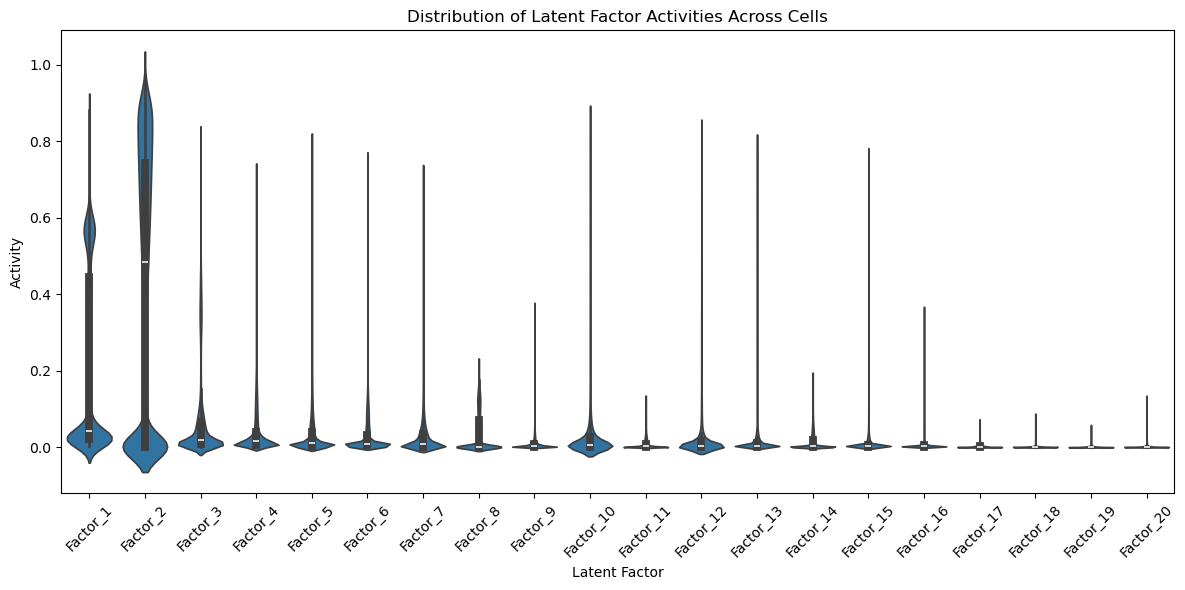

In [12]:
# Extract X_PHI matrix and convert to DataFrame
phi = pd.DataFrame(
    filtered_splice_adata.obsm["X_PHI"],
    index=filtered_splice_adata.obs["cell_id"]
)
phi.columns = [f"Factor_{i+1}" for i in range(phi.shape[1])]

phi_long = phi.reset_index().melt(id_vars="cell_id", var_name="Factor", value_name="Activity")

# Plot
plt.figure(figsize=(12, 6))  # Adjust width as needed
sns.violinplot(data=phi_long, x="Factor", y="Activity", inner="box", scale="width")
plt.xticks(rotation=45)
plt.title("Distribution of Latent Factor Activities Across Cells")
plt.xlabel("Latent Factor")
plt.ylabel("Activity")
plt.tight_layout()
plt.show()

In [13]:
# Clean up Broad Cell Type column
filtered_splice_adata.obs["broad_cell_type"] = filtered_splice_adata.obs["broad_cell_type"].str.title()
filtered_ge_adata.obs["age_numeric"] = filtered_splice_adata.obs["age_numeric"]
filtered_ge_adata.obs["broad_cell_type"] = filtered_splice_adata.obs["broad_cell_type"]

In [14]:
# Setup
phi_matrix = filtered_splice_adata.obsm["X_PHI"]
factor_names = [f"Factor_{i+1}" for i in range(phi_matrix.shape[1])]

# Build DataFrame
phi_df = pd.DataFrame(phi_matrix, index=filtered_splice_adata.obs_names, columns=factor_names)
phi_df["broad_cell_type"] = filtered_splice_adata.obs["broad_cell_type"].values
phi_df["age_group"] = filtered_splice_adata.obs["age_group"].values
phi_df["lifespan_category"] = filtered_splice_adata.obs["lifespan_category"].values

# Output dirs
output_dir_celltype = "./factor_violin_plots_by_celltype"
output_dir_agegroup = "./factor_violin_plots_by_agegroup"
output_dir_factors_by_celltype = "./factor_violin_per_celltype"

os.makedirs(output_dir_factors_by_celltype, exist_ok=True)
os.makedirs(output_dir_celltype, exist_ok=True)
os.makedirs(output_dir_agegroup, exist_ok=True)

In [15]:
# Toggle this to enable or disable plotting
MAKE_PLOTS = False

if MAKE_PLOTS:
    # --- Plot factor activity across broad cell types ---
    for factor in factor_names:
        # Order broad_cell_type by decreasing median activity
        medians = phi_df.groupby("broad_cell_type")[factor].median().sort_values(ascending=False)
        ordered_types = medians.index.tolist()

        plt.figure(figsize=(10, 5))
        sns.violinplot(
            data=phi_df, x="broad_cell_type", y=factor,
            order=ordered_types, inner="box", scale="width",
            fill="simple_category"
        )
        plt.xticks(rotation=45, ha='right')
        plt.title(f"{factor} Activity Across Broad Cell Types")
        plt.xlabel("Broad Cell Type")
        plt.ylabel("Factor Activity")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir_celltype, f"{factor}_by_celltype_violin.pdf"))
        plt.close()

    # --- Plot factor activity across age groups ---
    for factor in factor_names:
        # Define age group order (assumes string labels like "3m", "18m", etc.)
        age_order = phi_df["age_group"].unique().tolist()
        age_order.sort()

        plt.figure(figsize=(6, 5))
        sns.violinplot(
            data=phi_df, x="age_group", y=factor,
            order=age_order, inner="box", scale="width"
        )
        plt.title(f"{factor} Activity Across Age Groups")
        plt.xlabel("Age Group")
        plt.ylabel("Factor Activity")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir_agegroup, f"{factor}_by_agegroup_violin.pdf"))
        plt.close()

    # --- Melt wide-format dataframe into long-form for factor plotting ---
    phi_long = phi_df.reset_index().melt(
        id_vars=["cell_id", "broad_cell_type", "age_group"],
        value_vars=factor_names,
        var_name="Factor", value_name="Activity"
    )

    # --- Plot violin plots of all factors within each cell type ---
    for celltype in phi_df["broad_cell_type"].unique():
        # Subset data to current cell type
        subset = phi_long[phi_long["broad_cell_type"] == celltype]

        # Order factors by median activity within the current cell type
        median_order = (
            subset.groupby("Factor")["Activity"]
            .median()
            .sort_values(ascending=False)
            .index.tolist()
        )

        plt.figure(figsize=(14, 5))
        sns.violinplot(
            data=subset, x="Factor", y="Activity",
            order=median_order, inner="box", scale="width"
        )
        plt.xticks(rotation=45, ha='right')
        plt.title(f"Factor Activity in {celltype} (Ordered by Median)")
        plt.xlabel("Factor")
        plt.ylabel("Activity")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir_factors_by_celltype, f"{celltype}_factor_activity_violin.pdf"))
        plt.close()

## Visualize Perplexity

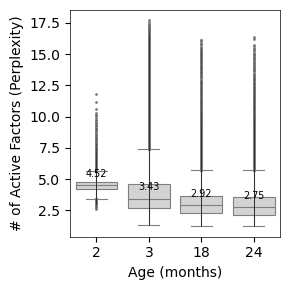

In [16]:
# Step 2: Reindex to match AnnData.obs_names (i.e., cell IDs)
perplexity_df = perplexity_df.reindex(filtered_splice_adata.obs_names)

# Step 3: Add as a new column in AnnData.obs
filtered_splice_adata.obs["perplexity"] = perplexity_df["perplexity"].values

plt.figure(figsize=(3, 3))
sns.boxplot(
    data=filtered_splice_adata.obs,
    x="age_numeric", 
    y="perplexity", 
    color="lightgray", 
    fliersize=1, 
    linewidth=0.8
)
sns.stripplot(
    data=filtered_splice_adata.obs,
    x="age_numeric", 
    y="perplexity", 
    color="darkslategrey", 
    size=0.5, 
    jitter=False,
    alpha=0.3
)

# Add median labels
medians = (
    filtered_splice_adata.obs
    .groupby("age_numeric", observed=True)["perplexity"]
    .median()
)
for i, (age, median_val) in enumerate(medians.items()):
    plt.text(
        x=i,
        y=median_val + 0.5,
        s=f"{median_val:.2f}",
        ha='center',
        va='bottom',
        fontsize=7,
        color='black'
    )

plt.xlabel("Age (months)", fontsize=10)
plt.ylabel("# of Active Factors (Perplexity)", fontsize=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

for spine in plt.gca().spines.values():
    spine.set_linewidth(0.5)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/perplexity_by_age.pdf", bbox_inches='tight')
plt.show()

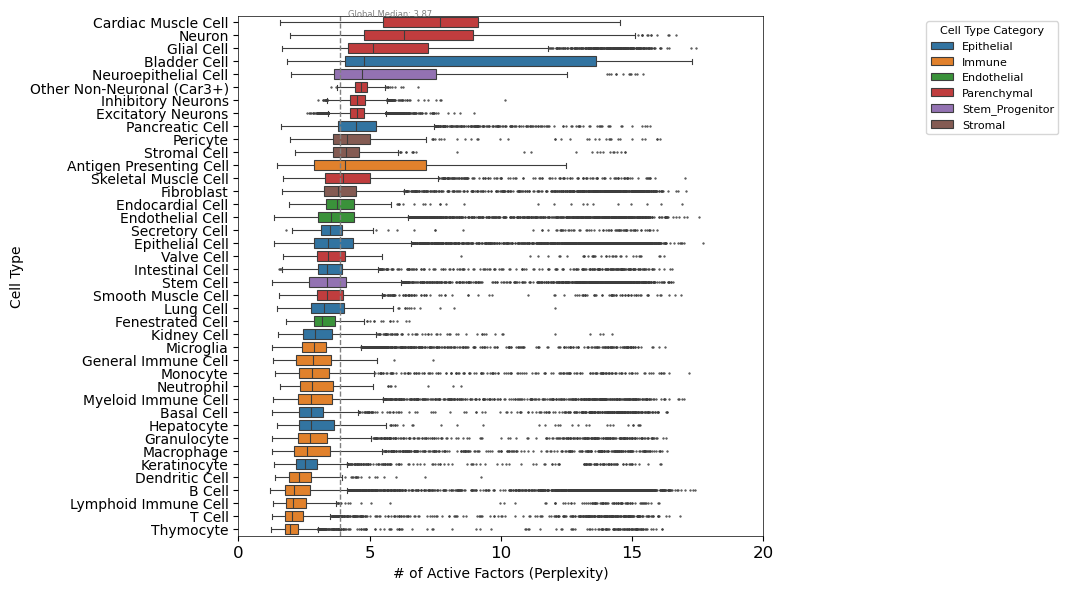

In [17]:
# Step 1: Compute median perplexity by broad_cell_type
median_order = (
    filtered_splice_adata.obs
    .groupby("broad_cell_type", observed=True)["perplexity"]
    .median()
    .sort_values(ascending=False)
    .index
)

# Step 2: Start figure FIRST
plt.figure(figsize=(12, 6))

# Step 3: Main plot
sns.boxplot(
    data=filtered_splice_adata.obs,
    y="broad_cell_type", 
    x="perplexity", 
    hue="simple_category", 
    fliersize=0.6, 
    linewidth=0.8,
    order=median_order
)

# Step 4: Add global median line and label
global_median = filtered_splice_adata.obs["perplexity"].median()
plt.axvline(global_median, color='gray', linestyle='--', linewidth=1)
plt.text(global_median + 0.3, -1, f"Global Median: {global_median:.2f}",
         color='gray', fontsize=6, va='top')

# Legend
plt.legend(
    title="Cell Type Category",
    bbox_to_anchor=(1.3, 1),
    loc='upper left',
    fontsize=8,
    title_fontsize=8,
    frameon=True
)

# Axis formatting
plt.ylabel("Cell Type", fontsize=10)
plt.xlabel("# of Active Factors (Perplexity)", fontsize=10)
plt.xticks(np.arange(0, 25, 5), fontsize=12)
plt.yticks(fontsize=10)

# Reduce thickness of the plot border (spines)
for spine in plt.gca().spines.values():
    spine.set_linewidth(0.5)  # default is usually ~1.0

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/perplexity_by_cell_type_ordered.pdf", bbox_inches='tight')
plt.show()

### Figure 2 Factor Covaraites Labels

In [18]:
# Remake PHI matrix correlation plot
X_PHI_corr_matrix = plot_correlation_matrix(filtered_splice_adata.obsm["X_PHI"], OUTPUT_DIR)

In [19]:
import sys
sys.path.append("/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils")

import utils  # or: from utils import your_function

import importlib
importlib.reload(utils)

<module 'utils' from '/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/utils.py'>

In [20]:
# read in factor labels 
factor_labels = utils.run_variance_explained_analysis(filtered_splice_adata, sample_id="dataset", PLOTS_DIR=OUTPUT_DIR)

Running variance explained analysis...


Analyzing factors for variance explained:   0%|          | 0/20 [00:00<?, ?it/s]

  Formula: Factor_1 ~ C(cell_type) + C(tissue) + C(sex) + C(dataset) + age + C(cell_type):age + C(tissue):age + C(sex):age


Analyzing factors for variance explained:   5%|▌         | 1/20 [00:07<02:17,  7.25s/it]

  Formula: Factor_2 ~ C(cell_type) + C(tissue) + C(sex) + C(dataset) + age + C(cell_type):age + C(tissue):age + C(sex):age


...

  Formula: Factor_19 ~ C(cell_type) + C(tissue) + C(sex) + C(dataset) + age + C(cell_type):age + C(tissue):age + C(sex):age


Analyzing factors for variance explained:  95%|█████████▌| 19/20 [02:13<00:07,  7.03s/it]

  Formula: Factor_20 ~ C(cell_type) + C(tissue) + C(sex) + C(dataset) + age + C(cell_type):age + C(tissue):age + C(sex):age


Analyzing factors for variance explained: 100%|██████████| 20/20 [02:20<00:00,  7.05s/it]


  Saved variance explained heatmap to /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-08/2025-07-10/param_id_0/analysis_outputs/variance_explained_heatmap.pdf


In [21]:
import sys
sys.path.append("/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils")
import figure_plotting
import importlib
importlib.reload(figure_plotting)

<module 'figure_plotting' from '/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/figure_plotting.py'>

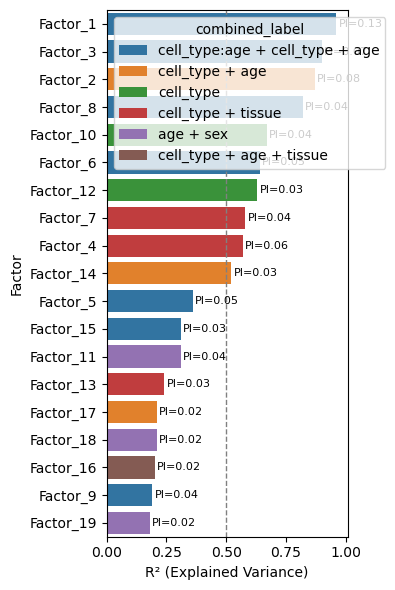

In [22]:
factor_labels['combined_label'] = factor_labels.apply(relabel_covariate, axis=1)
# Save a new ordered version of pi
new_pi = pi[new_order]
fig, ax = figure_plotting.plot_covariates_factor_labels(new_pi, factor_labels, save_path=f"{OUTPUT_DIR}/combined_labels_anova.pdf")

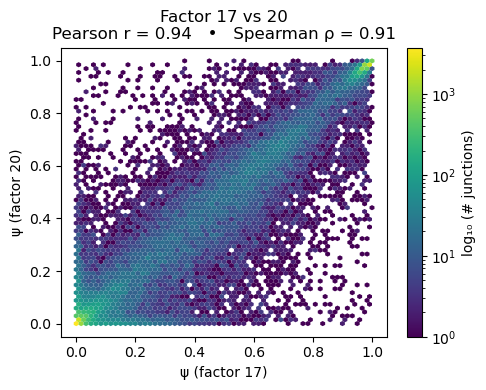

In [23]:
# examples ───────────────────────────────────────────────────────────────────
plot_factor_corr(filtered_splice_adata, f_x=17,  f_y=20)       # factors 2 vs 15, 1-based


Top 2 positively correlated factor pairs:
factor_i factor_j      rho
      F2      F13 0.656681
     F10      F13 0.627514

Top 2 negatively correlated factor pairs:
factor_i factor_j       rho
      F2      F19 -0.380732
     F10      F19 -0.365978

Top 2 least correlated factor pairs:
factor_i factor_j       rho
     F11      F17 -0.001869
      F1       F9 -0.001878


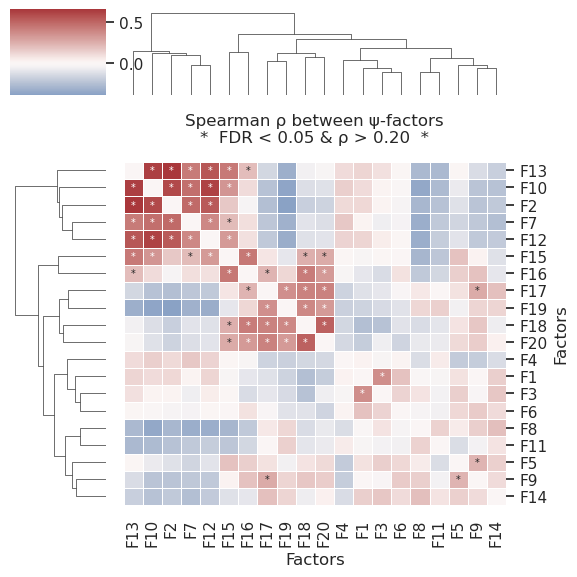

In [24]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests   # pip install statsmodels

# ── 1.  Data → DataFrame ───────────────────────────────────────────────────────
ψ  = filtered_splice_adata.varm["psi_learned"]          # (J, K)
K  = ψ.shape[1]

# Subtract row (junction) mean from each factor value
ψ_centered = ψ - np.nanmean(ψ, axis=1, keepdims=True)
K = ψ_centered.shape[1]
df = pd.DataFrame(ψ_centered, columns=[f"F{j+1}" for j in range(K)])

# ── 2.  ρ and p-values for *each* pair ─────────────────────────────────────────
rho    = np.zeros((K, K))
pvals  = np.ones((K, K))

for i in range(K):
    for j in range(i+1, K):
        r, p = spearmanr(df.iloc[:, i], df.iloc[:, j], nan_policy='omit')
        rho[i, j] = rho[j, i] = r
        pvals[i, j] = pvals[j, i] = p

# ── 3.  Benjamini–Hochberg FDR adjustment over the upper triangle ─────────────
tri_idx         = np.triu_indices(K, k=1)          # exclude the diagonal
p_flat          = pvals[tri_idx]
_, q_flat, _, _ = multipletests(p_flat, method="fdr_bh")
qvals           = np.ones_like(pvals)
qvals[tri_idx]  = qvals.T[tri_idx] = q_flat

# ── 4.  Significance mask  (FDR < 0.05 and ρ > 0.20) ──────────────────────────
star_mask = (qvals < 0.05) & (rho > 0.20)
annot     = np.where(star_mask, "*", "")

# ── 5.  Build DataFrames with indices/columns for seaborn ─────────────────────
rho_df   = pd.DataFrame(rho,   index=df.columns, columns=df.columns)
annot_df = pd.DataFrame(annot, index=df.columns, columns=df.columns)


# ── 1.  clustered heat-map with all tick labels ───────────────────────────────
sns.set_theme(style="white")
g = sns.clustermap(
    rho_df,
    cmap="vlag", center=0, linewidths=0.4, square=True,
    metric="euclidean", row_cluster=True, col_cluster=True,
    figsize=(6, 6),
    annot=annot_df, fmt="", annot_kws={"size":7},
    xticklabels=True, yticklabels=True
)

# Rotate x-labels so they don’t overlap
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)

g.ax_heatmap.set_title("Spearman ρ between ψ-factors\n*  FDR < 0.05 & ρ > 0.20  *", pad=14)
g.ax_heatmap.set_xlabel("Factors")
g.ax_heatmap.set_ylabel("Factors")

plt.tight_layout()

# ── 2.  save to disk ──────────────────────────────────────────────────────────
g.savefig(f"{OUTPUT_DIR}/psi_factor_spearman_clustermap.pdf", bbox_inches="tight")

# ── 3.  report extreme pairs ──────────────────────────────────────────────────
# flatten upper triangle (exclude diagonal), keep finite values only
tri_i, tri_j = np.triu_indices_from(rho_df, k=1)
tri_vals = rho_df.values[tri_i, tri_j]

# build a DataFrame for easy sorting
pairs_df = pd.DataFrame({
    "factor_i": rho_df.index[tri_i],
    "factor_j": rho_df.columns[tri_j],
    "rho":      tri_vals
}).dropna()

# top 2 positive
top_pos = pairs_df.nlargest(2, "rho")
# top 2 negative
top_neg = pairs_df.nsmallest(2, "rho")
# top 2 least correlated (closest to zero)
top_flat = pairs_df.iloc[(pairs_df["rho"].abs()).nsmallest(2).index]

print("\nTop 2 positively correlated factor pairs:")
print(top_pos.to_string(index=False))

print("\nTop 2 negatively correlated factor pairs:")
print(top_neg.to_string(index=False))

print("\nTop 2 least correlated factor pairs:")
print(top_flat.to_string(index=False))


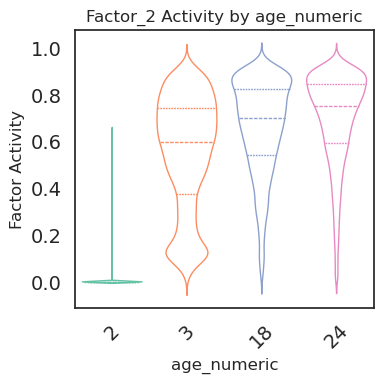

In [25]:
plot_factor_violin(
    adata=filtered_splice_adata,
    factor_list=["Factor_2"],
    groupby="age_numeric",
    save_prefix="factor_age_violin"
)

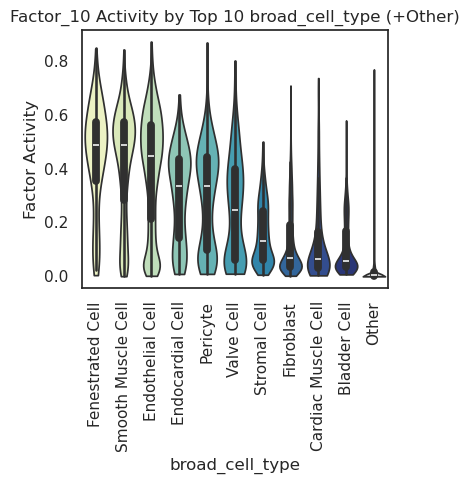

In [26]:
plot_factor_violin_sorted(
    adata=filtered_splice_adata,
    factor_list=["Factor_10"],
    groupby="broad_cell_type",
    top_n=10,
    cmap="YlGnBu",
    save_prefix="sorted_violin",
    width=4,
    height=5
)


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

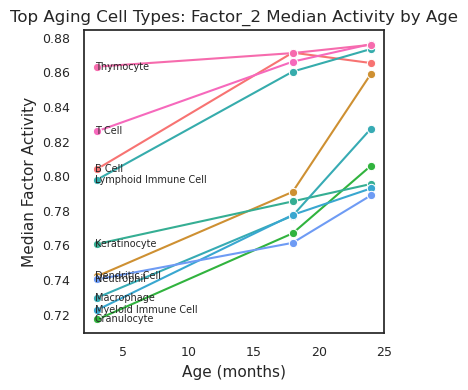

In [75]:
plot_factor_age_trends(
    df=filtered_splice_adata.obs,
    factor="Factor_2",
    top_n=10,
    title_prefix="Top Aging Cell Types",
    save_path=f"{OUTPUT_DIR}/Factor_2_age_trend_top5.pdf"
)


### Get heatmap for common cell types 

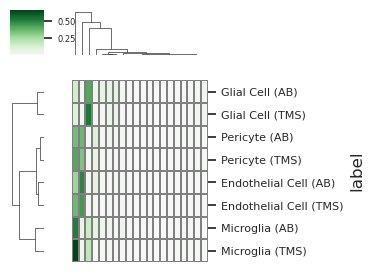

In [28]:
# Get cell type counts by dataset to get common cell types
# Get cell type counts by dataset to get common cell types
cell_type_counts = filtered_splice_adata.obs.groupby(['broad_cell_type', 'dataset']).size().unstack()
common_cell_types = cell_type_counts[(cell_type_counts["AB"] > 0) & (cell_type_counts["TMS"] > 0)]
common_cell_type_names = common_cell_types.index.tolist()

# Subset to common cell types
adata_common = filtered_splice_adata[
    filtered_splice_adata.obs["broad_cell_type"].isin(common_cell_type_names)
].copy()

# Convert to categorical first
adata_common.obs["broad_cell_type"] = adata_common.obs["broad_cell_type"].astype("category")
adata_common.obs["broad_cell_type"] = adata_common.obs["broad_cell_type"].cat.remove_unused_categories()

# Extract factor matrix and build DataFrame
num_factors = adata_common.obsm["X_PHI"].shape[1]
factor_cols = [f"Factor_{i+1}" for i in range(num_factors)]

df = adata_common.obs[["broad_cell_type", "dataset"]].copy()
for i, col in enumerate(factor_cols):
    df[col] = adata_common.obsm["X_PHI"][:, i]

# Compute median factor values by cell type and dataset
median_profiles = (
    df.groupby(["broad_cell_type", "dataset"], observed=True)[factor_cols]
    .median()
    .reset_index()
)

# Create composite labels
median_profiles["label"] = (
    median_profiles["broad_cell_type"].astype(str)
    + " (" +
    median_profiles["dataset"].astype(str)
    + ")"
)

# Set label as index
median_profiles = median_profiles.set_index("label")[factor_cols]

# Plot clustermap
g = sns.clustermap(
    median_profiles,
    method="average",
    metric="euclidean",
    cmap="PRGn",
    center=0,
    linewidths=0.2,
    linecolor='gray',
    figsize=(4, 3)
)

# Remove x-axis tick labels (factors)
g.ax_heatmap.set_xticks([])
g.ax_heatmap.set_xticklabels([])

# Format y-axis (cell types)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=8)

# Colorbar label and tick font
g.ax_cbar.set_label("Median Factor Activity")
g.ax_cbar.yaxis.label.set_size(7)
g.ax_cbar.tick_params(labelsize=6)

# Save
plt.tight_layout()
g.savefig(f"{OUTPUT_DIR}/clustering_common_celltype_dataset_factors.pdf", bbox_inches='tight')
plt.show()

In [29]:
filtered_splice_adata.obs["broad_cell_type"] = filtered_splice_adata.obs["broad_cell_type"].astype("category")

  broad_cell_type age_numeric  Factor_14
0    Bladder Cell           3   0.015403
1    Bladder Cell          18   0.000963
2    Bladder Cell          24   0.000892


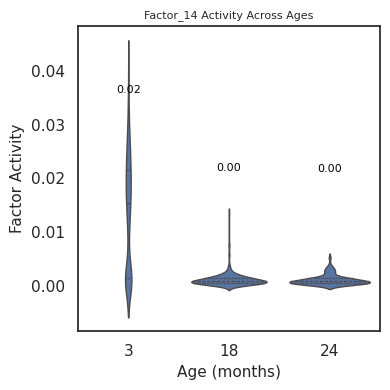

In [90]:
plot_factor_violin_by_age(
    df=filtered_splice_adata.obs,
    factor="Factor_14",
    cell_types=["Bladder Cell"],
    figsize=(4, 4), save_path=f"{OUTPUT_DIR}/F10_SecretoryCells.pdf"
)


In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Extract age and perplexity
X = filtered_splice_adata.obs[["age_numeric"]].values  # shape (n_cells, 1)
y = filtered_splice_adata.obs["perplexity"].values  # shape (n_cells,)

# Fit linear regression
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

# Compute R²
r2 = r2_score(y, y_pred)
print(f"R² (perplexity ~ age): {r2:.4f}")

R² (perplexity ~ age): 0.0919


In [32]:
filtered_splice_adata

AnnData object with n_obs × n_vars = 147979 × 39656
    obs: 'cell_id_index', 'age', 'cell_ontology_class', 'donor_id', 'sex', 'subtissue', 'tissue', 'dataset', 'cell_name', 'cell_id', 'cell_clean', 'broad_cell_type', 'seqtech', 'AgingScore_unweighted', 'AgingScore_pos', 'AgingScore_neg', 'nuclear_ratio_log_norm', 'age_numeric', 'age_group', 'total_counts', 'nuclear_class_log_norm', 'nuclear_score_log_norm', 'cell_type_module', 'functional_category', 'tissue_system', 'lifespan_category', 'simple_category', 'senescence_proneness', 'Factor_1', 'Factor_2', 'Factor_3', 'Factor_4', 'Factor_5', 'Factor_6', 'Factor_7', 'Factor_8', 'Factor_9', 'Factor_10', 'Factor_11', 'Factor_12', 'Factor_13', 'Factor_14', 'Factor_15', 'Factor_16', 'Factor_17', 'Factor_18', 'Factor_19', 'Factor_20', 'perplexity'
    var: 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'junction_conserved', 'n

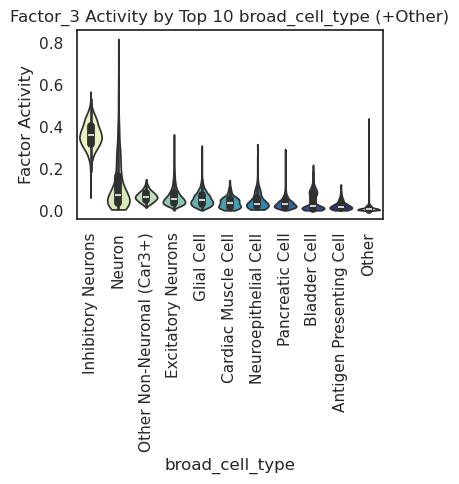

In [33]:
plot_factor_violin_sorted(
    adata=filtered_splice_adata,
    factor_list=["Factor_3"],
    groupby="broad_cell_type",
    top_n=10,
    cmap="YlGnBu",
    save_prefix="sorted_violin",
    width=4,
    height=5
)


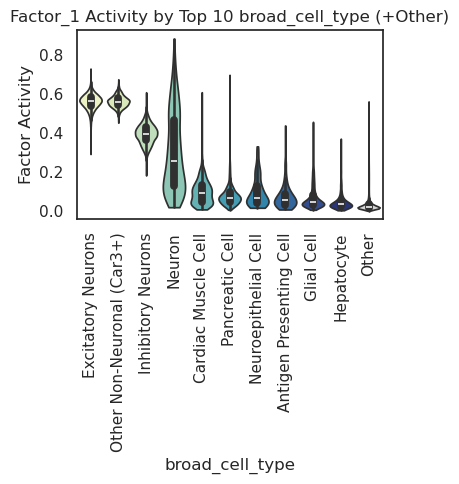

In [34]:
plot_factor_violin_sorted(
    adata=filtered_splice_adata,
    factor_list=["Factor_1"],
    groupby="broad_cell_type",
    top_n=10,
    cmap="YlGnBu",
    save_prefix="sorted_violin",
    width=4,
    height=5
)


### Look at sig junctions from differential splicing analysis

In [35]:
# Run the analysis
print("="*60)
print("TOP JUNCTIONS PER FACTOR PSI ANALYSIS")
print("="*60)

# Step 1: Get top junctions per factor
top_junctions_dict, subset_splice_adata, junction_factor_map = get_top_junctions_per_factor(
    diff_spl, 
    filtered_splice_adata, 
    top_n=10, 
    effect_size_col='abs_effect_size'
)

# Get unique junction indices
unique_junctions = junction_factor_map['junction_idx'].unique()

# Extract PSI learned values for these junctions
psi_subset = filtered_splice_adata.varm['psi_learned'][unique_junctions, :]

TOP JUNCTIONS PER FACTOR PSI ANALYSIS
Getting top 10 junctions per factor...
Ranking by: abs_effect_size
Found 20 factors: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Factor 0: 10 junctions, effect size range: 0.750 - 0.864
Factor 1: 10 junctions, effect size range: 0.971 - 0.994
Factor 2: 10 junctions, effect size range: 0.856 - 0.944
Factor 3: 10 junctions, effect size range: 0.891 - 0.984
Factor 4: 10 junctions, effect size range: 0.863 - 0.926
Factor 5: 10 junctions, effect size range: 0.891 - 0.968
Factor 6: 10 junctions, effect size range: 0.966 - 0.989
Factor 7: 10 junctions, effect size range: 0.942 - 0.980
Factor 8: 10 junctions, effect size range: 0.767 - 0.809
Factor 9: 10 junctions, effect size range: 0.961 - 0.994
Factor 10: 10 junctions, effect size range: 0.916 - 0.953
Factor 11: 10 junctions, effect size range: 0.953 - 0.990
Factor 12: 10 junctions, effect size range: 0.696 - 0.768
Factor 13: 10 junctions, effect size range: 0.854 - 0.896
Fact

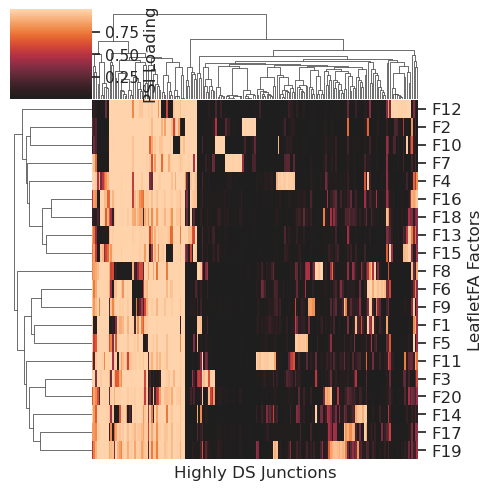

In [36]:
# 1. Map row labels: get junction_id or gene_name from .var
# Get the integer indices into .varm (which uses original order)
unique_junctions = junction_factor_map['junction_idx'].unique()
# psi_learned: shape (n_junctions, n_factors), so index using integer indices
psi_subset = filtered_splice_adata.varm['psi_learned'][unique_junctions, :]
junction_id = filtered_splice_adata.var[filtered_splice_adata.var["junction_id_index"].isin(unique_junctions)]["junction_id"].values
gene_name = filtered_splice_adata.var[filtered_splice_adata.var["junction_id_index"].isin(unique_junctions)]["gene_name"].values

# Get number of factors (rows after transpose)
num_factors = psi_subset.shape[1]

# Create factor labels: F1, F2, ..., FK
factor_labels = [f"F{i+1}" for i in range(num_factors)]

# 2. Create clustermap with color tweaks
g = sns.clustermap(
    psi_subset.T,
    center=0,
    figsize=(6, 5),
    xticklabels=False,
    yticklabels=factor_labels,
    cbar_kws={'label': 'PSI Loading'},
    robust=True  # clip extreme values for better contrast
)

# 3. Style adjustments
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=8)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=12)
g.ax_heatmap.set_ylabel("LeafletFA Factors")
g.ax_heatmap.set_xlabel("Highly DS Junctions")
plt.subplots_adjust(left=0.3, bottom=0.05, top=0.95, right=0.98)
save_path = os.path.join(OUTPUT_DIR, "psi_clustermap_top_10.pdf")
g.savefig(save_path, bbox_inches="tight")
plt.show()

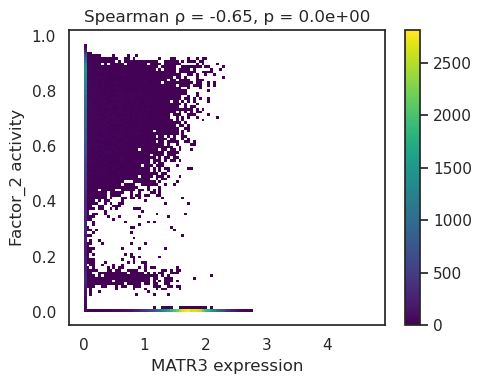

In [37]:
plot_gene_vs_factor_correlation(
    splice_adata=filtered_splice_adata,
    ge_adata=filtered_ge_adata,
    gene_name="MATR3",
    factor_col="Factor_2",
    plot_type="hist"  # try "scatter", "kde", or "hist"
)

### Get UMAP on X_PHI

In [38]:
# Run neighbors and UMAP on X_PHI embedding
# sc.pp.neighbors(filtered_splice_adata, use_rep="X_PHI", n_neighbors=8)
# sc.tl.umap(filtered_splice_adata, random_state=0, min_dist=0.3)

In [39]:
#plot_gene_and_factor_umap_from_phi(
#    splice_adata=filtered_splice_adata,
#    ge_adata=filtered_ge_adata,
#    gene_name="ZWINT",
#    factor_name="Factor_2",
#    groupby="broad_cell_type",
#    group_level="Microglia"
#)

### Summary plots for aging predictions

Filtered out 2 cell types with negative CV R² values
Plotting 23 cell types


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


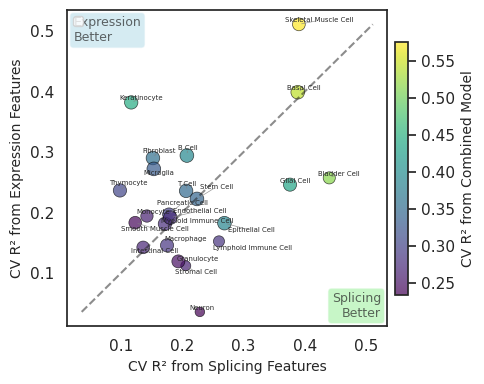

In [40]:
results_df, feature_importance, final_cell_types = compute_age_r2_with_cv_linear_regression(
     filtered_splice_adata, filtered_ge_adata, cv=5, show_top_features=15
 )

filtered_results = plot_cv_r2_scatter_with_labels(results_df, annotate_top_k=30, show_overfitting=True, save_path=f"{OUTPUT_DIR}/cv_r2_scatter.pdf")

results_df["diff"] = results_df["cv_r2_splicing"] - results_df["cv_r2_expression"]
# sort by absolute difference 
results_df["abs_diff"] = results_df["diff"].abs()
results_df = results_df.sort_values(by="abs_diff", ascending=True)

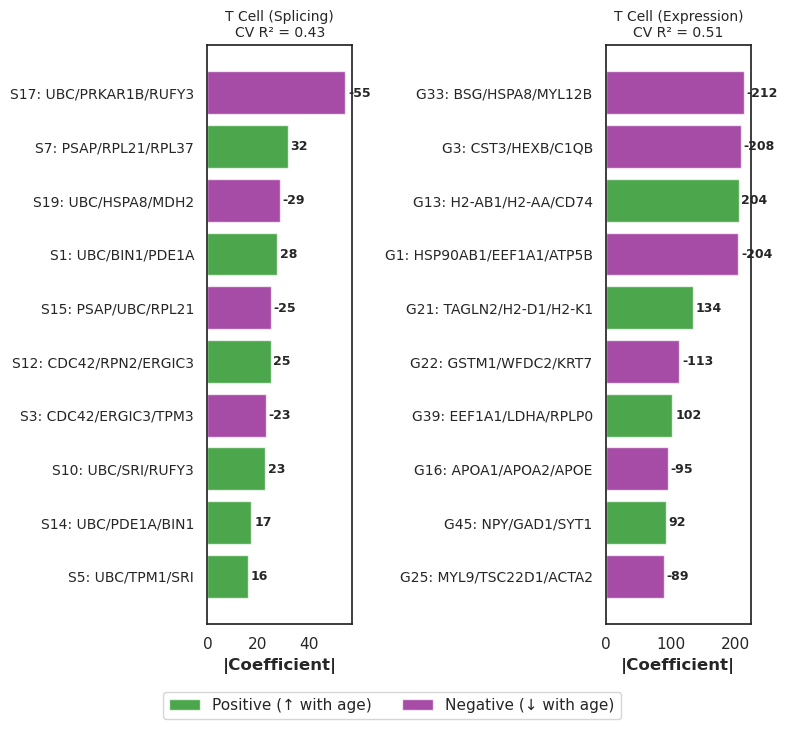


 CELL (Splicing) - Top 10 factors:
  S17: UBC/PRKAR1B/RUFY3: -54.5
  S7: PSAP/RPL21/RPL37: 31.8
  S19: UBC/HSPA8/MDH2: -28.6
  S1: UBC/BIN1/PDE1A: 27.6
  S15: PSAP/UBC/RPL21: -25.1
  S12: CDC42/RPN2/ERGIC3: 25.0
  S3: CDC42/ERGIC3/TPM3: -23.0
  S10: UBC/SRI/RUFY3: 22.7
  S14: UBC/PDE1A/BIN1: 17.4
  S5: UBC/TPM1/SRI: 16.1

 (Expression) - Top 10 factors:
  G33: BSG/HSPA8/MYL12B: -212.2
  G3: CST3/HEXB/C1QB: -207.8
  G13: H2-AB1/H2-AA/CD74: 204.4
  G1: HSP90AB1/EEF1A1/ATP5B: -204.0
  G21: TAGLN2/H2-D1/H2-K1: 134.5
  G22: GSTM1/WFDC2/KRT7: -112.7
  G39: EEF1A1/LDHA/RPLP0: 102.2
  G16: APOA1/APOA2/APOE: -95.3
  G45: NPY/GAD1/SYT1: 91.9
  G25: MYL9/TSC22D1/ACTA2: -89.2


In [41]:
# Get top 10 factors for BASAL CELL (splicing)
basal_splice = feature_importance["Bladder Cell"]["splicing_only"].head(10)
basal_labels = []
basal_coeffs = []

for i in range(10):
    factor_idx = int(basal_splice.iloc[i]["feature_idx"])
    coeff = basal_splice.iloc[i]["coefficient"]
    
    # Get top 3 junctions for this factor
    psi_values = splice_adata.varm["psi_learned"][:, factor_idx]
    top_junction_indices = np.argsort(np.abs(psi_values))[-3:][::-1]
    top_junction_ids = splice_adata.var["gene_name"].iloc[top_junction_indices]
    
    # Extract gene names
    top_genes = [jid.split(':')[0] for jid in top_junction_ids]
    label = '/'.join(top_genes)
    
    basal_labels.append(f"S{factor_idx}: {label}")
    basal_coeffs.append(coeff)

# Get top 10 factors for SKELETAL MUSCLE (expression)
skeletal_ge = feature_importance["Skeletal Muscle Cell"]["expression_only"].head(10)
skeletal_labels = []
skeletal_coeffs = []

for i in range(10):
    factor_idx = int(skeletal_ge.iloc[i]["feature_idx"])
    coeff = skeletal_ge.iloc[i]["coefficient"]
    
    # Get top 3 genes for this factor
    nmf_weights = ge_adata.varm["nmf_standard_mb_components"][:, factor_idx]
    top_gene_indices = np.argsort(np.abs(nmf_weights))[-3:][::-1]
    top_gene_names = ge_adata.var["gene_name"].iloc[top_gene_indices]
    
    label = '/'.join(top_gene_names)
    skeletal_labels.append(f"G{factor_idx+1}: {label}")
    skeletal_coeffs.append(coeff)

# Create side-by-side bar plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 7))

# Left: Basal Cell (Splicing)
y_pos1 = np.arange(10)
colors1 = ['purple' if x < 0 else 'green' for x in basal_coeffs]
bars1 = ax1.barh(y_pos1, np.abs(basal_coeffs), color=colors1, alpha=0.7)

ax1.set_yticks(y_pos1)
ax1.set_yticklabels(basal_labels, fontsize=10)
ax1.set_xlabel('|Coefficient|', fontsize=12, weight='bold')
ax1.set_title('T Cell (Splicing)\nCV R² = 0.43', fontsize=10)
ax1.invert_yaxis()

# Add coefficient values
for i, (bar, coef) in enumerate(zip(bars1, basal_coeffs)):
    ax1.text(bar.get_width() + max(np.abs(basal_coeffs)) * 0.02,
             bar.get_y() + bar.get_height()/2, f'{coef:.0f}',
             va='center', fontsize=9, weight='bold')

# Right: Skeletal Muscle (Expression)
y_pos2 = np.arange(10)
colors2 = ['purple' if x < 0 else 'green' for x in skeletal_coeffs]
bars2 = ax2.barh(y_pos2, np.abs(skeletal_coeffs), color=colors2, alpha=0.7)

ax2.set_yticks(y_pos2)
ax2.set_yticklabels(skeletal_labels, fontsize=10)
ax2.set_xlabel('|Coefficient|', fontsize=12, weight='bold')
ax2.set_title('T Cell (Expression)\nCV R² = 0.51', fontsize=10)
ax2.invert_yaxis()

# Add coefficient values
for i, (bar, coef) in enumerate(zip(bars2, skeletal_coeffs)):
    ax2.text(bar.get_width() + max(np.abs(skeletal_coeffs)) * 0.02,
             bar.get_y() + bar.get_height()/2, f'{coef:.0f}',
             va='center', fontsize=9, weight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='Green', alpha=0.7, label='Positive (↑ with age)'),
    Patch(facecolor='Purple', alpha=0.7, label='Negative (↓ with age)')
]
fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=2)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/panel_e_feature_D_cells_comparison.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Print summary
print("\n CELL (Splicing) - Top 10 factors:")
for label, coeff in zip(basal_labels, basal_coeffs):
    print(f"  {label}: {coeff:.1f}")

print("\n (Expression) - Top 10 factors:")
for label, coeff in zip(skeletal_labels, skeletal_coeffs):
    print(f"  {label}: {coeff:.1f}")

In [42]:
# Initialize: dictionary to store per-cell-type median activity for each factor
from collections import defaultdict

nonzero_median_activity_by_celltype = {}

# Get all unique cell types
cell_types = filtered_splice_adata.obs["broad_cell_type"].unique()

# Matrix: shape (n_cells, n_factors)
phi_matrix = filtered_splice_adata.obsm["X_PHI"]

# Loop over cell types
for ct in cell_types:
    mask = filtered_splice_adata.obs["broad_cell_type"] == ct
    phi_ct = phi_matrix[mask.values]  # subset matrix

    # Compute median of non-zero values per factor
    nonzero_median = np.median(
        np.where(phi_ct > 0, phi_ct, np.nan), axis=0
    )
    nonzero_median = np.nan_to_num(nonzero_median, nan=0.0)
    
    nonzero_median_activity_by_celltype[ct] = nonzero_median

# Annotate all cell-type-specific splicing models with activity-weighted coefficients
adjusted_feature_importance = defaultdict(list)

for ct in final_cell_types:  # only those that passed thresholds
    if ct not in feature_importance:
        continue

    median_activity = nonzero_median_activity_by_celltype[ct]
    
    # Get top splicing features
    splice_df = feature_importance[ct]["splicing_only"].copy()
    splice_df["cell_type"] = ct
    splice_df["nonzero_median_activity"] = splice_df["feature_idx"].map(lambda i: median_activity[i])
    splice_df["activity_weighted"] = splice_df["coefficient"] * splice_df["nonzero_median_activity"]

    adjusted_feature_importance[ct] = splice_df

# Flatten across all cell types
adjusted_splice_df_all = pd.concat(adjusted_feature_importance.values(), ignore_index=True)

# Optional: rank top features across all cell types by activity-weighted value
adjusted_splice_df_all["abs_activity_weighted"] = adjusted_splice_df_all["activity_weighted"].abs()
adjusted_splice_df_all = adjusted_splice_df_all.sort_values("abs_activity_weighted", ascending=False)

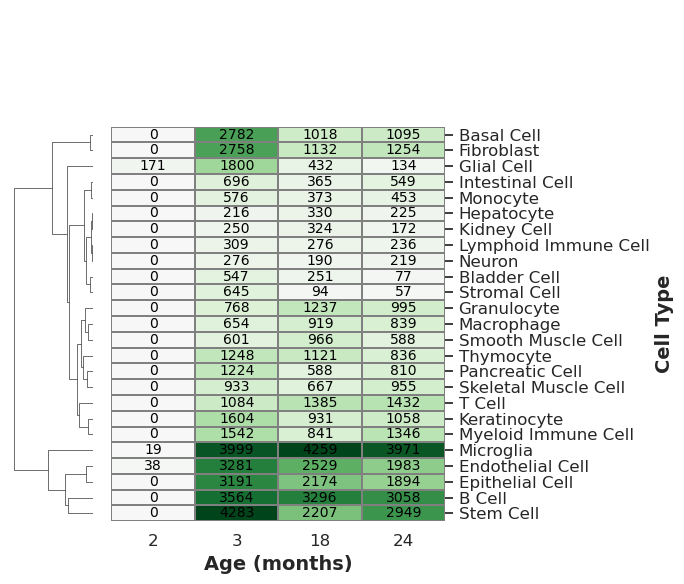

Clustermap shows 25 cell types across 4 ages
Total cells plotted: 94,149


In [43]:
# Example usage (add this to your existing code):
crosstab = plot_simple_age_celltype_heatmap(filtered_splice_adata, final_cell_types, save_path=f"{OUTPUT_DIR}/simple_heatmap.pdf")

### Color this plot with cell type category

Analyzing 147979 total cells
Number of cell types: 40
Created 40 tissue type indicators
Splicing features: 20
Expression features: 50

Running 10-fold cross-validation...
  Testing Tissue Only (40 features)...
    Mean R²: 0.3814 ± 0.0046
  Testing Tissue + Expression (90 features)...
    Mean R²: 0.4120 ± 0.0047
  Testing Tissue + Splicing (60 features)...
    Mean R²: 0.4829 ± 0.0059
  Testing All Features (110 features)...
    Mean R²: 0.4989 ± 0.0058

Fitting final global model on all features to extract top coefficients...

Top 20 features by absolute coefficient:
      feature  coefficient  abs_coefficient
57  Splice_18   -84.696737        84.696737
58  Splice_19   -65.989358        65.989358
55  Splice_16    47.302538        47.302538
56  Splice_17   -45.455792        45.455792
52  Splice_13    38.504907        38.504907
54  Splice_15    35.115800        35.115800
43   Splice_4   -33.233242        33.233242
41   Splice_2    19.877171        19.877171
47   Splice_8    14.861127  

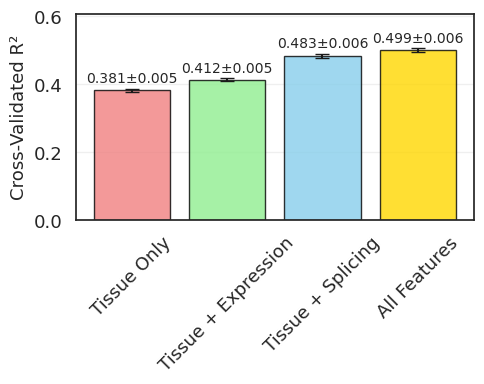

In [ ]:
# Example usage:
results_df, detailed_scores, top_features_df = global_age_prediction_analysis(
    filtered_splice_adata,
    filtered_ge_adata
)

# Top 10 splicing or expression factors:
print(top_features_df[top_features_df["feature"].str.startswith("Splice")].head(10))

# Fix xaxis ticks so normally aligned 
plot_global_results(results_df, detailed_scores, save_path=f"{OUTPUT_DIR}/global_age_prediction.pdf")

In [45]:
X_PHI = filtered_splice_adata.obsm["X_PHI"]

# Boolean mask for non-zero activity
nonzero_mask = X_PHI > 0

# Number of cells with non-zero activity per factor
n_nonzero = nonzero_mask.sum(axis=0)

# Sum of activities where non-zero
sum_nonzero = (X_PHI * nonzero_mask).sum(axis=0)

# Non-zero mean activity (set to 0 if never used)
nonzero_mean_activity = np.divide(sum_nonzero, n_nonzero, out=np.zeros_like(sum_nonzero), where=n_nonzero!=0)

coef_df = top_features_df
coefs = coef_df[coef_df['feature'].str.startswith("Splice")].copy()
coefs["factor_index"] = coefs["feature"].str.extract(r"Splice_(\d+)").astype(int) - 1
coefs["nonzero_mean_activity"] = coefs["factor_index"].map(lambda i: nonzero_mean_activity[i])
coefs["activity_weighted"] = coefs["coefficient"] * coefs["nonzero_mean_activity"]
coefs_sorted = coefs.sort_values("activity_weighted", key=lambda x: x.abs(), ascending=False)
# View top
coefs_sorted

,feature,coefficient,abs_coefficient,factor_index,nonzero_mean_activity,activity_weighted
41,Splice_2,19.877171,19.877171,1,0.411913,8.187656
40,Splice_1,10.113171,10.113171,0,0.201897,2.041815
43,Splice_4,-33.233242,33.233242,3,0.035776,-1.188965
42,Splice_3,9.039335,9.039335,2,0.068553,0.619675
49,Splice_10,10.979754,10.979754,9,0.052380,0.575114
47,Splice_8,14.861127,14.861127,7,0.036046,0.535678
52,Splice_13,38.504907,38.504907,12,0.012066,0.464598
46,Splice_7,12.230202,12.230202,6,0.033894,0.414527
54,Splice_15,35.115800,35.115800,14,0.008790,0.308677
45,Splice_6,9.732450,9.732450,5,0.027042,0.263188


In [46]:
filtered_splice_adata.obs["lifespan_category"].value_counts()

lifespan_category
Long_Lived        74742
Medium_Lived      34221
Variable_Lived    21838
Short_Lived       17178
Name: count, dtype: int64

### New circle heatmap combining delta age and activity across cell types

In [47]:
from scipy.cluster.hierarchy import dendrogram, linkage
from matplotlib.patches import Circle
import matplotlib.cm as cm

def plot_factor_circles(adata, cell_type_col='broad_cell_type', age_col='age_group'):
    """
    Create clustered circle heatmap from AnnData object
    
    Parameters:
    -----------
    adata : AnnData object with factors in obsm['X_PHI']
    cell_type_col : column name for cell types
    age_col : column name for age groups (should have 'young' and 'old')
    """
    
    # Extract factor data from PHI matrix
    X_PHI = adata.obsm["X_PHI"]
    n_factors = X_PHI.shape[1]
    factor_cols = [f"Factor_{i+1}" for i in range(n_factors)]
    
    # Create DataFrame from PHI matrix
    factor_df = pd.DataFrame(X_PHI, index=adata.obs.index, columns=factor_cols)
        
    # 1. Calculate median expression per cell type (non-zero cells only)
    median_expr = pd.DataFrame(index=adata.obs[cell_type_col].unique(), columns=factor_cols)
    
    for ct in median_expr.index:
        ct_mask = adata.obs[cell_type_col] == ct
        ct_data = factor_df.loc[ct_mask]
        
        # Calculate median of non-zero values for each factor
        for factor in factor_cols:
            factor_values = ct_data[factor]
            non_zero_values = factor_values[factor_values > 0]
            if len(non_zero_values) > 0:
                median_expr.loc[ct, factor] = non_zero_values.median()
            else:
                median_expr.loc[ct, factor] = 0
    
    # Convert to numeric and fill NaN
    median_expr = median_expr.astype(float).fillna(0)
    
    # 2. Calculate delta (old - young) per cell type using non-zero medians
    delta_age = pd.DataFrame(index=median_expr.index, columns=factor_cols)
    
    for ct in median_expr.index:
        ct_mask = adata.obs[cell_type_col] == ct
        
        # Get old and young cells
        old_mask = ct_mask & (adata.obs[age_col] == 'old')
        young_mask = ct_mask & (adata.obs[age_col] == 'young')
        
        if old_mask.sum() > 10 and young_mask.sum() > 10:  # Min cells
            for factor in factor_cols:
                
                # Median of non-zero cells only
                old_values = factor_df.loc[old_mask, factor]
                young_values = factor_df.loc[young_mask, factor]
                delta_age.loc[ct, factor] = old_values.median() - young_values.median()
        else:
            delta_age.loc[ct] = 0
    
    delta_age = delta_age.astype(float).fillna(0)
    
    # 3. Cluster factors by expression patterns
    factor_linkage = linkage(median_expr.T, method='ward')
    factor_order = dendrogram(factor_linkage, no_plot=True)['leaves']
    
    # Cluster cell types
    celltype_linkage = linkage(median_expr, method='ward')
    celltype_order = dendrogram(celltype_linkage, no_plot=True)['leaves']
    celltype_order = [median_expr.index[i] for i in celltype_order]
    
    # Reorder
    median_ordered = median_expr.loc[celltype_order, :].iloc[:, factor_order]
    delta_ordered = delta_age.loc[celltype_order, :].iloc[:, factor_order]
    
    # 4. Create figure without dendrograms
    fig, ax_main = plt.subplots(figsize=(7, 5))
    
    # 5. Plot circles
    n_cells = len(median_ordered)
    n_factors = len(median_ordered.columns)
    
    ax_main.set_xlim(-0.5, n_factors - 0.5)
    ax_main.set_ylim(-0.5, n_cells - 0.5)
    
    # Colormap setup - simple symmetric range
    cmap = plt.cm.BrBG
    vmax = max(abs(delta_ordered.min().min()), abs(delta_ordered.max().max()))
    norm = plt.Normalize(vmin=-vmax, vmax=vmax)
    
    # Plot each circle
    min_size = 0.05  # Minimum visible circle size
    
    for i, cell_type in enumerate(median_ordered.index):
        for j, factor in enumerate(median_ordered.columns):
            expr = median_ordered.iloc[i, j]
            delta = delta_ordered.iloc[i, j]
            
            if expr > 0.001:  # Lower threshold to catch more factors
                # Log transform expression for better visualization
                log_expr = np.log10(expr + 0.01)
                
                # Size with minimum threshold
                size = max(min_size, (log_expr + 2) * 0.15)  # Adjust scaling
                
                # Color by age change
                color = cmap(norm(delta))
                
                circle = Circle((j, i), size, 
                              facecolor=color, 
                              edgecolor='black',
                              linewidth=0.2,
                              alpha=1)
                ax_main.add_patch(circle)
    
    # Labels
    ax_main.set_xticks(range(n_factors))
    ax_main.set_xticklabels(median_ordered.columns, rotation=45, ha='right', fontsize=9)
    ax_main.set_yticks(range(n_cells))
    ax_main.set_yticklabels(median_ordered.index, fontsize=7)

    # Grid
    ax_main.grid(True, alpha=0.3, linestyle=':')
    ax_main.set_axisbelow(True)
    
    # Colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax_main, label='Activity change with age (Old - Young)', shrink=0.8)
    
    plt.tight_layout()
    return fig

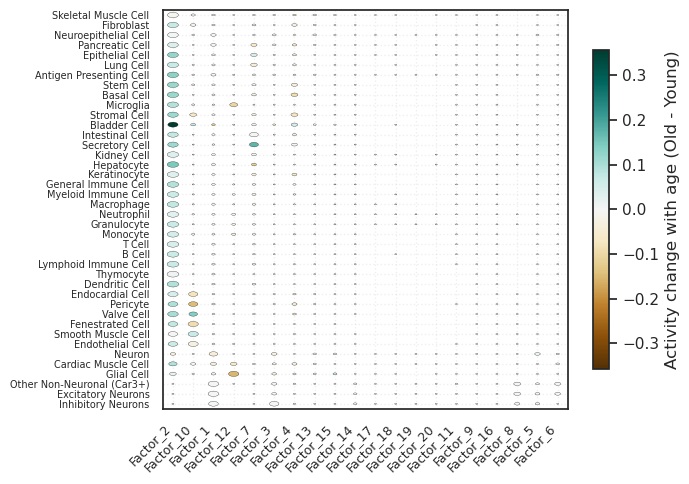

In [48]:
fig = plot_factor_circles(filtered_splice_adata)
plt.savefig(f"{OUTPUT_DIR}/delta_median_old_minus_young_by_broad_cell_type_dot_heatmap.pdf", format="pdf", bbox_inches='tight')

In [49]:
filtered_ge_adata

AnnData object with n_obs × n_vars = 147979 × 13394
    obs: 'cell_id', 'age', 'cell_ontology_class', 'mouse.id', 'sex', 'tissue', 'dataset', 'batch', 'subtissue_clean', 'broad_cell_type', 'cell_id_index', 'cell_name', 'library_size', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_is_rRNA', 'log1p_total_counts_is_rRNA', 'pct_counts_is_rRNA', 'nuclear_score_log_norm', 'nuclear_ratio_log_norm', 'nuclear_rrna_log_norm', 'nuclear_class_log_norm', 'nuclear_score_predicted_log_norm_tms', 'nuclear_ratio_predicted_log_norm_tms', 'nuclear_rrna_predicted_log_norm_tms', 'nuclear_class_predicted_log_norm_tms', 'AgingScore_pos', 'AgingScore_neg', 'AgingScore_unweighted', 'age_numeric'
    var: 'index', 'gene_name', 'gene_id', 'mean_transcript_length', 'mean_intron_length', 'num_transcripts', 'transcript_biotypes', 'is_rRNA', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'hi

In [50]:
# Get data
top_k_genes = 5
fdr_thresh = 0.05
rho_thresh = 0.2 

X_PHI = filtered_splice_adata.obsm["X_PHI"]
X_NMF = filtered_ge_adata.obsm["X_nmf_standard_mb"]
nmf_components = filtered_ge_adata.varm["nmf_standard_mb_components"]  # genes × components
gene_names = filtered_ge_adata.var["gene_name"].values

n_nmf = X_NMF.shape[1]
n_factors = X_PHI.shape[1]

# Build factor dataframe
factor_df = pd.DataFrame(X_PHI, columns=[f"Factor{i+1}" for i in range(n_factors)])
nmf_names = [f"NMF{i+1}" for i in range(n_nmf)]

# Get top-k genes per NMF component
top_genes_dict = {}
for i, comp in enumerate(nmf_names):
    weights = nmf_components[:, i]
    top_idx = np.argsort(-np.abs(weights))[:top_k_genes]
    top_genes = gene_names[top_idx]
    top_genes_dict[comp] = top_genes.tolist()

# Compute correlation and p-value matrices
corr_matrix = np.zeros((n_nmf, n_factors))
pval_matrix = np.zeros((n_nmf, n_factors))

for i in range(n_nmf):
    nmf_activity = X_NMF[:, i]
    for j in range(n_factors):
        rho, pval = spearmanr(nmf_activity, X_PHI[:, j])
        corr_matrix[i, j] = rho
        pval_matrix[i, j] = pval

# FDR correction
_, pvals_fdr_flat, _, _ = multipletests(pval_matrix.flatten(), method='fdr_bh')
fdr_matrix = pvals_fdr_flat.reshape(pval_matrix.shape)

# Annotations for clustermap
annot_matrix = np.where(
        (fdr_matrix < fdr_thresh) & (np.abs(corr_matrix) > rho_thresh),
        "*",
        ""
    )

# Build labels with top genes
nmf_labels = [f"{nmf} ({', '.join(top_genes_dict[nmf])})" for nmf in nmf_names]

# Convert to DataFrame
corr_df = pd.DataFrame(corr_matrix, index=nmf_labels, columns=factor_df.columns)
fdr_df = pd.DataFrame(fdr_matrix, index=nmf_labels, columns=factor_df.columns)

# Save correlation and FDR matrices
corr_df.to_csv(os.path.join(OUTPUT_DIR, "gene_nmf_factor_correlations.csv"))
fdr_df.to_csv(os.path.join(OUTPUT_DIR, "gene_nmf_factor_fdr.csv"))

# Plot clustermap
g = sns.clustermap(
    corr_df,
    cmap="PRGn",
    center=0,
    linewidths=0.2,
    linecolor="black",
    xticklabels=True,
    yticklabels=True,
    annot=annot_matrix,
    fmt='',
    annot_kws={'size': 6, 'color': 'black'},
    figsize=(6,8)
)

# Axes labels
g.ax_heatmap.set_xlabel("Splicing Factors", fontsize=12)
g.ax_heatmap.set_ylabel("Gene NMF Components", fontsize=12)

# Tick labels font size
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, ha="right", fontsize=8)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=6)  # ← smaller font for NMF labels

# Colorbar (legend) font size
g.cax.tick_params(labelsize=6)  # ← smaller ticks on colorbar
g.cax.set_ylabel(g.cax.get_ylabel(), fontsize=8)  # ← smaller colorbar label

# Save
g.savefig(os.path.join(OUTPUT_DIR, "gene_nmf_factor_correlation_clustermap.pdf"), dpi=300, bbox_inches='tight')
plt.close(g.fig)


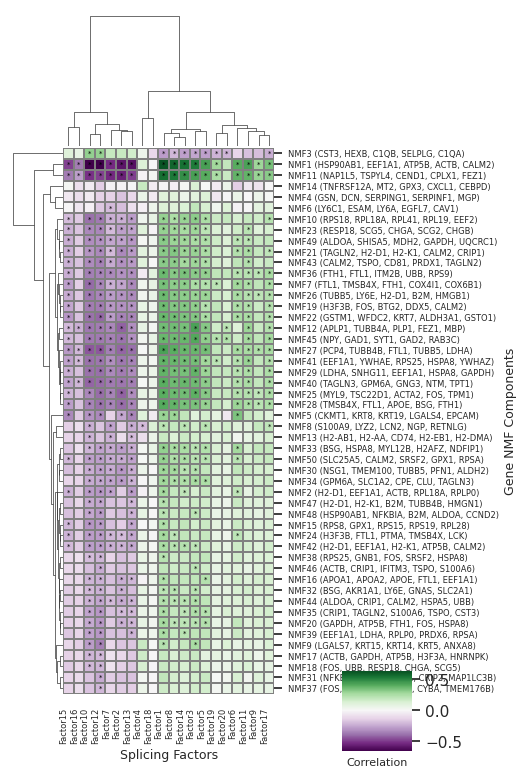

In [51]:
# Build labels with top genes
nmf_labels = [f"{nmf} ({', '.join(top_genes_dict[nmf])})" for nmf in nmf_names]

# Convert to DataFrame
corr_df = pd.DataFrame(corr_matrix, index=nmf_labels, columns=factor_df.columns)
fdr_df = pd.DataFrame(fdr_matrix, index=nmf_labels, columns=factor_df.columns)

# Save correlation and FDR matrices
corr_df.to_csv(os.path.join(OUTPUT_DIR, "gene_nmf_factor_correlations.csv"))
fdr_df.to_csv(os.path.join(OUTPUT_DIR, "gene_nmf_factor_fdr.csv"))

# Plot clustermap with horizontal colorbar
g = sns.clustermap(
    corr_df,
    cmap="PRGn",
    center=0,
    linewidth=0.05,
    linecolor="grey",
    xticklabels=True,
    yticklabels=True,
    annot=annot_matrix,
    fmt='',
    annot_kws={'size': 5, 'color': 'black'},
    figsize=(7,8),
    cbar_pos=(0.5, 0.05, 0.1, 0.1)  # (x, y, width, height) for horizontal colorbar
)

# Axis labels (smaller font)
g.ax_heatmap.set_xlabel("Splicing Factors", fontsize=9)
g.ax_heatmap.set_ylabel("Gene NMF Components", fontsize=9)

# Tick labels (smaller font)
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, ha="right", fontsize=6)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=6)

# Colorbar label and ticks
g.cax.tick_params(labelsize=4, axis='x')  # ↓ smaller tick labels
g.cax.set_xlabel("Correlation", fontsize=8)

# Save
g.savefig(os.path.join(OUTPUT_DIR, "gene_nmf_factor_correlation_clustermap.pdf"), dpi=300, bbox_inches='tight')
plt.show()


In [52]:
diff_spl["factor_idx"].value_counts()

factor_idx
7     9133
3     6791
1     6018
0     5950
10    5376
4     5304
6     5020
5     4925
13    4426
2     4354
9     4186
11    4120
8     2318
14    2093
12    1978
18    1477
19    1261
16    1157
15    1054
17     764
Name: count, dtype: int64

In [53]:
def plot_factor_junction_annotation_counts(final_df, output_path):
    """
    Create a stacked barplot showing the number of significant junctions per factor,
    colored by junction annotation category.
    """
    # Count unique junctions by (factor, annotation)
    counts = (
        final_df.groupby(["factor_idx", "junction_annotation"])["junction_id_index"]
        .nunique()
        .reset_index(name="count")
    )
    # Add factor name column
    counts["factor_name"] = "Factor_" + (counts["factor_idx"] +1).astype(str)
    # Pivot to wide format: rows=factor_name, columns=annotation, values=count
    pivot_df = counts.pivot(index="factor_name", columns="junction_annotation", values="count").fillna(0)
    # print table
    print(pivot_df)
    # Sort by total number of junctions
    pivot_df["total"] = pivot_df.sum(axis=1)
    pivot_df = pivot_df.sort_values("total", ascending=False)
    pivot_df = pivot_df.drop(columns="total")
    # Plot
    plt.figure(figsize=(6, 3))
    pivot_df.plot(
        kind="bar",
        stacked=True,
        colormap="viridis",  # Or use sns.color_palette("Set2", n_colors=...)
        edgecolor="black"
    )
    plt.title("Number of Significant Junctions per Factor by Annotation", fontsize=14, fontweight="bold")
    plt.xlabel("Factor", fontsize=12)
    plt.ylabel("Number of Significant Junctions", fontsize=12)
    plt.xticks(rotation=45, ha="right", fontsize=10)
    plt.yticks(fontsize=10)
    plt.legend(title="Junction Annotation", fontsize=9, title_fontsize=10, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    # Save
    plt.savefig(output_path, dpi=300)
    plt.close()

In [54]:
plot_factor_junction_annotation_counts(diff_spl, os.path.join(OUTPUT_DIR, "differential_splicing_annotation_counts_barplot.pdf"))

junction_annotation  3_prime_annotated  5_prime_annotated  Both_SS_annotated  \
factor_name                                                                    
Factor_1                         138.0              156.0             5640.0   
Factor_10                        153.0              107.0             3920.0   
Factor_11                        231.0              269.0             4873.0   
Factor_12                        151.0               92.0             3866.0   
Factor_13                         77.0               56.0             1842.0   
Factor_14                        260.0              254.0             3906.0   
Factor_15                         75.0               53.0             1958.0   
Factor_16                         33.0               27.0              994.0   
Factor_17                         37.0               43.0             1077.0   
Factor_18                         26.0               19.0              719.0   
Factor_19                         76.0  

<Figure size 600x300 with 0 Axes>

In [55]:
def plot_junction_factor_distribution(final_df, output_path):
    """Create an improved histogram showing distribution of factors per junction"""
    # Get counts of factors/junction
    junc_counts = final_df.groupby("junction_id_index")["factor_idx"].nunique()
    junc_counts_df = pd.DataFrame({"junction_id_index": junc_counts.index, "num_factors": junc_counts.values})
    # Create figure with appropriate size
    plt.figure(figsize=(6, 5))
    # Create histogram with better styling
    ax = sns.histplot(junc_counts_df["num_factors"], bins=range(1, junc_counts_df["num_factors"].max() + 2), 
                     kde=True, color='steelblue', edgecolor='darkblue', alpha=0.7)
    # Add mean line
    mean_factors = junc_counts_df["num_factors"].mean()
    plt.axvline(mean_factors, color='red', linestyle='--', linewidth=2)
    plt.text(mean_factors + 0.2, plt.ylim()[1]*0.9, f'Mean: {mean_factors:.2f}', 
             color='red', fontweight='bold')
    # Add title and labels with better formatting
    plt.title("Distribution of Factors per Junction (Significant Only)", fontsize=14, fontweight='bold')
    plt.xlabel("Number of factors affecting junction", fontsize=12)
    plt.ylabel("Count of junctions", fontsize=12)
    # Add grid for better readability
    plt.grid(axis='y', alpha=0.3)
    # Adjust layout
    plt.tight_layout()
    # Save figure with higher DPI
    plt.savefig(output_path, dpi=300)
    plt.close()

In [56]:
plot_junction_factor_distribution(diff_spl, os.path.join(OUTPUT_DIR, "differential_splicing_barplot.pdf"))

In [57]:
# Reset junction_id_index column 
psi_samples = leaflet_model["psi_samples"]
filtered_splice_adata.var["junction_id_index"] = np.arange(filtered_splice_adata.n_vars)
print("\n>> Running analysis functions...")
results = ds.analyze_all_factors_psi(psi_samples, top_junctions=filtered_splice_adata.var["junction_id_index"].values, min_effect_size=0.2)
all_results = []

for factor_idx, (effect_size_list, significance_df) in results.items():
    # Append to list
    all_results.append(significance_df)
    print("\n>> Running analysis functions...")

# Concatenate all results into a single DataFrame
final_df = pd.concat(all_results, ignore_index=True)
final_df["junction_id_index"] = final_df["junction_idx"]
# convert splice_adata.var["junction_id_index"] to dtype int64
filtered_splice_adata.var["junction_id_index"] = filtered_splice_adata.var["junction_id_index"].astype("int64")

# Merge with adata.var using junction_id_index
final_df = final_df.merge(filtered_splice_adata.var, on="junction_id_index")


>> Running analysis functions...
Analyzing differential splicing for 20 factors...
Finding DS junctions in factor 0 vs. all others


100%|██████████| 39656/39656 [00:21<00:00, 1837.17it/s]


Found 6791 significant junctions with effect size > 0.2 at FDR < 0.05
Finding DS junctions in factor 1 vs. all others


100%|██████████| 39656/39656 [00:21<00:00, 1856.73it/s]


Found 5950 significant junctions with effect size > 0.2 at FDR < 0.05
Finding DS junctions in factor 2 vs. all others


...

Found 1157 significant junctions with effect size > 0.2 at FDR < 0.05
Finding DS junctions in factor 18 vs. all others


100%|██████████| 39656/39656 [00:21<00:00, 1874.44it/s]


Found 4426 significant junctions with effect size > 0.2 at FDR < 0.05
Finding DS junctions in factor 19 vs. all others


100%|██████████| 39656/39656 [00:21<00:00, 1887.59it/s]


Found 1261 significant junctions with effect size > 0.2 at FDR < 0.05

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...

>> Running analysis functions...


In [58]:
# Step 2: Rename and map
final_df = final_df.rename(columns={"factor_idx": "old_factor_idx"})
final_df["factor_idx"] = final_df["old_factor_idx"].map(old_to_new_factor_idx)

In [59]:
# Create boolean masks for gene types
is_aging_gene = final_df["gene_name"].isin(aging_genes_mouse)
is_rbp_gene = final_df["gene_name"].isin(rbps)

# Initialize junction_label with 'Other'
final_df["junction_label"] = "Other"
final_df.loc[is_rbp_gene, "junction_label"] = "RBP"
final_df.loc[is_aging_gene, "junction_label"] = "Aging"

# Set 'Aging+RBP' if it's both (this will overwrite 'Aging' or 'RBP' if applicable)
final_df.loc[is_aging_gene & is_rbp_gene, "junction_label"] = "Aging+RBP"
final_df = final_df.merge(atse_df, on="junction_id")
print(final_df.junction_label.value_counts())

junction_label
Other        756120
RBP           23480
Aging         11020
Aging+RBP      2500
Name: count, dtype: int64


In [60]:
final_df["factor_idx"].min()

0

In [61]:
def plot_individual_factor_junction_analysis(final_df, results_dir, top_n=50):
    """
    Create individual plots for each factor showing their effect on top junctions.
    
    Args:
        final_df: DataFrame with columns ['junction_id_index', 'gene_name', 'junction_label', 'factor_idx', 'effect_size']
        results_dir: Base results directory
        top_n: Number of top junctions to show per factor
    """
    
    # Create DS_FACTORS directory
    ds_factors_dir = os.path.join(results_dir, "DS_FACTORS")
    os.makedirs(ds_factors_dir, exist_ok=True)
    print(f"Creating individual factor plots in: {ds_factors_dir}")
    
    # Junction type color mapping
    label_colors_map = {"Aging": "gold", "RBP": "lightgreen", "Aging+RBP": "orange", "Other": "lightgray"}
    
    # Get unique factors
    unique_factors = sorted(final_df["factor_idx"].unique())
    print(f"Found {len(unique_factors)} factors to analyze")
    
    for factor_idx in unique_factors:
        
        print(f"  Processing Factor_{factor_idx+1}...")
        
        # Filter data for this factor
        factor_df = final_df[final_df["factor_idx"] == factor_idx].copy()
        
        # Get top N junctions by absolute effect size for this factor
        factor_df["abs_effect_size"] = factor_df["effect_size"].abs()
        top_junctions = factor_df.nlargest(top_n, "abs_effect_size")
                
        # Create publication-ready plot with 3 subplots
        # Calculate height based on number of junctions (min 6", max 12")
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 7), 
                                            gridspec_kw={'width_ratios': [3.5, 1.25, 1.25]})
        
        # Set publication-ready style
        plt.rcParams.update({
            'font.size': 10,
            'axes.titlesize': 12,
            'axes.labelsize': 11,
            'xtick.labelsize': 9,
            'ytick.labelsize': 9,
            'legend.fontsize': 9,
            'figure.titlesize': 14
        })
        
        # ---- Left plot: Horizontal bar chart of effect sizes ----
        
        # Prepare data for plotting
        plot_data = top_junctions.copy()
        plot_data["display_label"] = plot_data.apply(
            lambda row: f"{row['gene_name_x']} (J{row['junction_id_index']})", axis=1
        )
        
        # Sort by effect size for better visualization
        plot_data = plot_data.sort_values("effect_size", ascending=True)
        
        # Create color array based on junction labels
        colors = [label_colors_map.get(label, "lightgray") for label in plot_data["junction_label"]]
        
        # Create horizontal bar plot with publication styling
        bars = ax1.barh(range(len(plot_data)), plot_data["effect_size"], 
                       color=colors, edgecolor='black', linewidth=0.8, alpha=0.85)
        
        # Customize left plot with publication standards
        ax1.set_yticks(range(len(plot_data)))
        ax1.set_yticklabels(plot_data["display_label"], fontsize=8)
        ax1.set_xlabel("Effect Size", fontsize=11, fontweight='bold')
        ax1.set_title(f"Factor {factor_idx+1}: Top {len(plot_data)} Affected Junctions", 
                     fontsize=12, fontweight='bold', pad=15)
        ax1.axvline(x=0, color='black', linestyle='-', linewidth=1.0)
        ax1.grid(axis='x', alpha=0.4, linewidth=0.5)
        ax1.spines['top'].set_visible(False)
        ax1.spines['right'].set_visible(False)
        ax1.spines['left'].set_linewidth(0.8)
        ax1.spines['bottom'].set_linewidth(0.8)
        
        # Add effect size values on bars with better formatting
        for i, (bar, effect) in enumerate(zip(bars, plot_data["effect_size"])):
            width = bar.get_width()
            x_pos = width + (0.02 if width >= 0 else -0.02)
            ha = 'left' if width >= 0 else 'right'
            ax1.text(x_pos, bar.get_y() + bar.get_height()/2, f'{effect:.3f}', 
                    ha=ha, va='center', fontsize=7, fontweight='normal')
        
        # ---- Right plot 1: Junction type distribution ----
        
        # Count junction types
        type_counts = plot_data["junction_label"].value_counts()
        
        # Create publication-ready pie chart
        colors_pie = [label_colors_map.get(label, "lightgray") for label in type_counts.index]
        wedges, texts, autotexts = ax2.pie(type_counts.values, labels=type_counts.index, 
                                          colors=colors_pie, autopct='%1.1f%%', 
                                          startangle=90, textprops={'fontsize': 8},
                                          wedgeprops={'linewidth': 0.8, 'edgecolor': 'white'})
        
        # Style the percentage labels
        for autotext in autotexts:
            autotext.set_color('black')
            autotext.set_fontweight('bold')
            autotext.set_fontsize(8)
        
        ax2.set_title(f"Junction Type\n(n={len(plot_data)})", 
                     fontsize=10, fontweight='bold', pad=10)
        
        # ---- Right plot 2: Junction annotation distribution ----
        
        # Count junction annotations (if the column exists)
        if 'junction_annotation' in plot_data.columns:
            annotation_counts = plot_data["junction_annotation"].value_counts()
            
            # Create publication-ready color palette for annotations
            n_annotations = len(annotation_counts)
            annotation_colors = plt.cm.Set3(np.linspace(0, 1, n_annotations))
            
            # Create pie chart for annotations with publication styling
            wedges3, texts3, autotexts3 = ax3.pie(annotation_counts.values, 
                                                  labels=annotation_counts.index, 
                                                  colors=annotation_colors, 
                                                  autopct='%1.1f%%', 
                                                  startangle=90, 
                                                  textprops={'fontsize': 7},
                                                  wedgeprops={'linewidth': 0.8, 'edgecolor': 'white'})
            
            # Style the percentage labels
            for autotext in autotexts3:
                autotext.set_color('black')
                autotext.set_fontweight('bold')
                autotext.set_fontsize(7)
            
            ax3.set_title(f"Junction Annotation\n(n={len(plot_data)})", 
                         fontsize=10, fontweight='bold', pad=10)
        else:
            # If junction_annotation column doesn't exist, show a clean message
            ax3.text(0.5, 0.5, 'Junction annotation\ndata not available', 
                    ha='center', va='center', fontsize=10,
                    bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgray', 
                             alpha=0.3, edgecolor='gray', linewidth=0.8))
            ax3.set_title("Junction Annotation", fontsize=10, fontweight='bold', pad=10)
            ax3.set_xlim(-1, 1)
            ax3.set_ylim(-1, 1)
            ax3.axis('off')
                
        # ---- Create publication-ready legend ----
        
        # Create legend for junction types
        legend_handles = [plt.Rectangle((0,0),1,1, color=color, label=label, 
                                       edgecolor='black', linewidth=0.5) 
                         for label, color in label_colors_map.items() 
                         if label in plot_data["junction_label"].values]
        
        if legend_handles:  # Only create legend if there are items
            fig.legend(handles=legend_handles, 
                      title="Junction Type", 
                      loc="lower center", 
                      bbox_to_anchor=(0.5, -0.02),
                      ncol=min(4, len(legend_handles)),
                      frameon=True, 
                      fontsize=9, 
                      title_fontsize=10,
                      edgecolor='black',
                      fancybox=True,
                      shadow=True)
        
        # ---- Save publication-ready plot ----
        
        plt.tight_layout(rect=[0, 0.08, 1, 0.97])  # Better spacing for publication
        
        output_path = os.path.join(ds_factors_dir, f"Factor_{factor_idx+1}_junction_analysis.pdf")
        plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
        plt.close()
        
        print(f"    ✓ Saved: factor_{factor_idx+1}_junction_analysis.pdf")
            
        # ---- Make junction-specific clustermap ----
            
        print(f"    Creating junction-specific clustermap for factor_{factor_idx+1}...")
            
        # Get the top junction IDs for this factor
        top_junction_ids = top_junctions["junction_id_index"].unique()
            
        # Filter final_df to get ALL factor effects on these specific junctions
        junction_specific_df = final_df[final_df["junction_id_index"].isin(top_junction_ids)].copy()
            
        if not junction_specific_df.empty and len(junction_specific_df["factor_idx"].unique()) > 1:
            # Create pivot table: rows=junctions, columns=factors, values=effect_size
            clustermap_data = junction_specific_df.pivot_table(
                index=["junction_id_index", "gene_name_x", "junction_label"],
                columns="factor_idx",
                values="effect_size",
                fill_value=0
            )
            
            # Rename columns to include "factor_" prefix
            clustermap_data.columns = [f"Factor_{col+1}" for col in clustermap_data.columns]
            
            # Prepare row colors based on junction_label
            junction_types_for_colors = clustermap_data.index.get_level_values("junction_label")
            row_color_series = junction_types_for_colors.map(label_colors_map).rename("Junction Type")
            row_colors_df = row_color_series.to_frame()
            
            # Prepare display labels for y-axis
            display_row_labels = [f"{gene} (J{jid})" for jid, gene, _ in clustermap_data.index]
            clustermap_data_display = clustermap_data.copy()
            clustermap_data_display.index = display_row_labels
            row_colors_df.index = display_row_labels
            
            g = sns.clustermap(
                clustermap_data_display,
                row_colors=row_colors_df,
                cmap="RdBu_r",
                center=0,
                annot=False,
                linewidths=0.3,
                figsize=(6, 7),
                cbar_kws={'label': 'Effect Size'},
                xticklabels=True,
                yticklabels=True
            )
            
            # Highlight the current factor column
            current_factor_col = f"Factor_{factor_idx+1}"
            if current_factor_col in clustermap_data_display.columns:
                # Find the position of the current factor in the reordered columns
                col_order = g.dendrogram_col.reordered_ind
                reordered_cols = clustermap_data_display.columns[col_order]
                if current_factor_col in reordered_cols:
                    highlight_pos = list(reordered_cols).index(current_factor_col)
                    
                    # Add a thick border around the highlighted column
                    ax_heatmap = g.ax_heatmap
                    ax_heatmap.axvline(x=highlight_pos, color='yellow', linewidth=3, alpha=0.8)
                    ax_heatmap.axvline(x=highlight_pos + 1, color='yellow', linewidth=3, alpha=0.8)
            
            # Customize the plot
            plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=9)
            plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=8)
            
            # Add title
            g.fig.suptitle(f'All Factor Effects on Top {len(top_junction_ids)} Junctions from Factor {factor_idx+1}\\n(Yellow highlight = Factor {factor_idx})', 
                          fontsize=12, fontweight='bold', y=0.98)
            
            # Create legend for junction types
            legend_handles = [plt.Rectangle((0,0),1,1, color=color, label=label) 
                             for label, color in label_colors_map.items() 
                             if label in junction_types_for_colors.values]
            
            g.fig.legend(handles=legend_handles, 
                        title="Junction Type", 
                        loc="upper left", 
                        bbox_to_anchor=(0.02, 0.95),
                        frameon=True, 
                        fontsize=9, 
                        title_fontsize=10)
            
            # Save the clustermap
            clustermap_path = os.path.join(ds_factors_dir, f"Factor_{factor_idx+1}_junction_clustermap.pdf")
            g.savefig(clustermap_path, dpi=300, bbox_inches='tight')
            plt.close(g.fig)
            
            print(f"    ✓ Saved junction clustermap: Factor_{factor_idx+1}_junction_clustermap.pdf")
        else:
            print(f"    ⚠️ Insufficient data for clustermap (factor_{factor_idx})")
        
        print(f"    ✓ Completed analysis for Factor_{factor_idx+1}")
        print()
        
    return ds_factors_dir

In [62]:
final_df["gene_name_x"]

0          KITL
1          KITL
2          KITL
3          KITL
4          KITL
          ...  
793115    DDX3Y
793116    KDM5D
793117    KDM5D
793118    KDM5D
793119    KDM5D
Name: gene_name_x, Length: 793120, dtype: category
Categories (7719, object): ['0610005C13RIK', '0610009B22RIK', '0610010F05RIK', '0610037L13RIK', ..., 'ZWINT', 'ZYG11B', 'ZYX', 'ZZZ3']

In [63]:
plot_individual_factor_junction_analysis(final_df, OUTPUT_DIR, top_n=50)

Creating individual factor plots in: /gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-08/2025-07-10/param_id_0/analysis_outputs/DS_FACTORS
Found 20 factors to analyze
  Processing Factor_1...
    ✓ Saved: factor_1_junction_analysis.pdf
    Creating junction-specific clustermap for factor_1...
    ✓ Saved junction clustermap: Factor_1_junction_clustermap.pdf
    ✓ Completed analysis for Factor_1

  Processing Factor_2...
    ✓ Saved: factor_2_junction_analysis.pdf
    Creating junction-specific clustermap for factor_2...
    ✓ Saved junction clustermap: Factor_2_junction_clustermap.pdf
    ✓ Completed analysis for Factor_2

  Processing Factor_3...
    ✓ Saved: factor_3_junction_analysis.pdf
    Creating junction-specific clustermap for factor_3...
    ✓ Saved junction clustermap: Factor_3_junction_clustermap.pdf
    ✓ Completed analysis for Factor_3

  Processing Factor_4...
    ✓ Saved: factor_4_junction_analysis.pdf
   

'/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/MOUSE_FOUNDATION/results/2025-07-08/2025-07-10/param_id_0/analysis_outputs/DS_FACTORS'

In [64]:
filtered_splice_adata.var[filtered_splice_adata.var["gene_name"] == "MACF1"]

,junction_id,event_id,splice_motif,annotation_status,gene_name,gene_id,num_junctions,position_off_5_prime,position_off_3_prime,CountJuncs,...,mean_counts_per_cell,junction_variability,annotation_status_score,expression_breadth_score,read_count_score,variability_score,conservation_score,junction_id_index,RBP_gene,Aging_gene
24776,chr4_123351951_123354478_-,ENSMUSG00000028649.18_atse_11,GT-AG,both,MACF1,ENSMUSG00000028649,3,1.0,0.0,16055,...,9.341534,0.523353,0.5,0.000000,9.465835,1.0,1.0,24776,False,True
24777,chr4_123351951_123355055_-,ENSMUSG00000028649.18_atse_11,GT-AG,both,MACF1,ENSMUSG00000028649,3,1.0,0.0,224835,...,8.429992,0.011001,0.5,2.647021,12.005088,0.5,1.0,24777,False,True
24778,chr4_123354580_123355055_-,ENSMUSG00000028649.18_atse_11,GT-AG,both,MACF1,ENSMUSG00000028649,3,1.0,0.0,15495,...,9.846972,0.510623,0.5,0.000000,9.395491,1.0,1.0,24778,False,True
24779,chr4_123355267_123358650_-,ENSMUSG00000028649.18_atse_10,GT-AG,three_prime,MACF1,ENSMUSG00000028649,2,NaN,0.0,4605,...,3.053448,0.361761,0.8,0.000000,8.172729,1.0,1.0,24779,False,True
24780,chr4_123355267_123360909_-,ENSMUSG00000028649.18_atse_10,GT-AG,both,MACF1,ENSMUSG00000028649,2,1.0,0.0,180333,...,7.611137,0.000000,0.5,2.523053,11.768823,0.5,1.0,24780,False,True
24781,chr4_123361027_123364056_-,ENSMUSG00000028649.18_atse_9,GT-AG,both,MACF1,ENSMUSG00000028649,3,1.0,0.0,82861,...,4.413441,0.940107,0.5,2.419978,11.111283,1.5,1.0,24781,False,True
24782,chr4_123361027_123365272_-,ENSMUSG00000028649.18_atse_9,GT-AG,both,MACF1,ENSMUSG00000028649,3,1.0,0.0,93784,...,29.609803,0.114168,0.5,0.000000,11.028726,0.5,1.0,24782,False,True
24783,chr4_123364074_123365272_-,ENSMUSG00000028649.18_atse_9,GT-AG,both,MACF1,ENSMUSG00000028649,3,1.0,0.0,70767,...,4.027462,0.865065,0.5,2.353463,10.946517,1.5,1.0,24783,False,True
24784,chr4_123368037_123368820_-,ENSMUSG00000028649.18_atse_8,GT-AG,both,MACF1,ENSMUSG00000028649,4,1.0,0.0,15147,...,2.556442,0.517806,0.5,0.000000,9.458684,1.0,1.0,24784,False,True
24785,chr4_123368037_123369804_-,ENSMUSG00000028649.18_atse_8,GT-AG,both,MACF1,ENSMUSG00000028649,4,1.0,0.0,89489,...,6.954040,0.082412,0.5,1.982800,11.073769,0.5,1.0,24785,False,True


Unique transcripts: ['ENSMUST00000082108.11', 'ENSMUST00000084301.11', 'ENSMUST00000097897.10', 'ENSMUST00000106213.7', 'ENSMUST00000106220.8', 'ENSMUST00000106224.7', 'ENSMUST00000123765.7', 'ENSMUST00000134458.7', 'ENSMUST00000149022.7', 'ENSMUST00000151346.7', 'ENSMUST00000154824.7']
Unique transcripts to remove: []
Plot saved to mouse_ENSMUSG00000028649.18_atse_9.pdf!


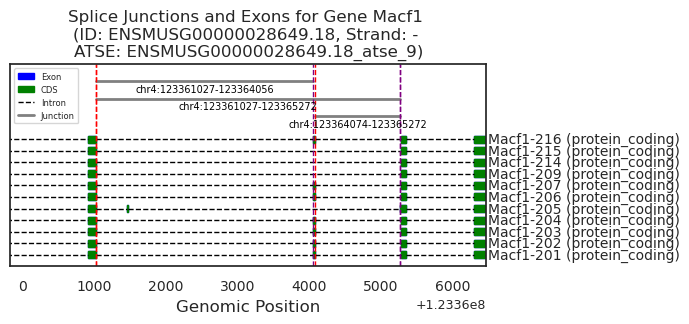

ATSE visualization saved: mouse_ENSMUSG00000028649.18_atse_9.pdf


{'junctions':                            event_id                gene_id gene_name  \
 29933  ENSMUSG00000028649.18_atse_9  ENSMUSG00000028649.18     Macf1   
 29934  ENSMUSG00000028649.18_atse_9  ENSMUSG00000028649.18     Macf1   
 29935  ENSMUSG00000028649.18_atse_9  ENSMUSG00000028649.18     Macf1   
 
            gene_types  num_junctions event_type chromosome strand  atse_start  \
 29933  protein_coding              3    complex       chr4      -   123361027   
 29934  protein_coding              3    complex       chr4      -   123361027   
 29935  protein_coding              3    complex       chr4      -   123361027   
 
         atse_end  ...  donor_total_reads  acceptor_total_reads  splice_motif  \
 29933  123365272  ...             164551                 70767         GT-AG   
 29934  123365272  ...             176645                164551         GT-AG   
 29935  123365272  ...              82861                176645         GT-AG   
 
        donor_seq  acceptor_seq  posi

In [65]:
mouse_event = "ENSMUSG00000028649.18_atse_9"
# need to fix by adding back columns to atse_df 
visualize_atse_event(mouse_event, atse_df, db_mouse,
                 species="mouse", base_width=7, 
                       trans_height=0.2, 
                  padding=200, show_junc_lines=True)

In [66]:
from sklearn.decomposition import PCA, NMF

def analyze_rbp_correlations(splice_adata, ge_adata, ge_layer_name="log_norm", PLOTS_DIR=None, DATA_DIR=None):
    """
    Analyze correlations between RBP gene expression and splicing factors
    
    Args:
        splice_adata: AnnData object with splicing data and X_PHI in obsm
        ge_adata: AnnData object with gene expression data
        ge_layer_name: Name of the layer in ge_adata to use for RBP expression
        PLOTS_DIR: Optional directory to save plot files.
        DATA_DIR: Optional directory to save data files.
    """
    print("Analyzing RBP correlations with splicing factors using NMF...")
    
    # Add assert statement to check that the two AnnData objects have the exact same cells in the same order
    assert np.all(splice_adata.obs["cell_id"].values == ge_adata.obs["cell_id"].values)
    
    # Ensure RBP_gene column exists in ge_adata.var
    if "RBP_gene" not in ge_adata.var.columns:
        print("  Error: 'RBP_gene' column not found in ge_adata.var")

    # Get RBP mask
    rbp_mask = ge_adata.var["RBP_gene"].values

    # Get RBP expression from input layer in ge_layer_name 
    rbp_expr = ge_adata.layers[ge_layer_name][:, rbp_mask]
    if scipy.sparse.issparse(rbp_expr):
        rbp_expr = rbp_expr.toarray()

    # Check for and clip negative values
    if np.any(rbp_expr < 0):
        print("  Warning: Negative values found in RBP expression data. Clipping to zero for NMF.")
        rbp_expr = np.clip(rbp_expr, 0, None)
    
    # Filter out genes with all-zero expression after potential clipping
    non_zero_genes_mask = np.any(rbp_expr > 0, axis=0) # NMF requires non-negative, so check for > 0
    rbp_expr = rbp_expr[:, non_zero_genes_mask]
    
    # Get the gene names after filtering
    rbp_gene_names = ge_adata.var["gene_name"].values[rbp_mask][non_zero_genes_mask]
    print(rbp_gene_names)
            
    print(f"  Analyzing {len(rbp_gene_names)} RBP genes with non-zero expression using NMF")
    
    # Perform NMF to get latent representation of RBPs
    n_components_nmf = min(10, rbp_expr.shape[1]) # Ensure n_components is not more than features
    nmf = NMF(n_components=n_components_nmf, init='nndsvda', random_state=42, max_iter=200)
    rbp_latent_nmf = nmf.fit_transform(rbp_expr)
    
    # Create a dictionary to store top RBPs per NMF component
    top_rbps_dict_nmf = {}
    
    # Get NMF components (loadings)
    nmf_components = pd.DataFrame(
        nmf.components_.T,
        index=rbp_gene_names,
        columns=[f"NMF{i+1}" for i in range(nmf.n_components_)]
    )
    
    # Get top RBPs per component
    for comp_col in nmf_components.columns:
        top_rbps = nmf_components[comp_col].abs().sort_values(ascending=False).head(10)
        top_rbps_dict_nmf[comp_col] = top_rbps.index.tolist()
    
    # Convert to a DataFrame
    top_rbps_df_nmf = pd.DataFrame.from_dict(top_rbps_dict_nmf, orient='index')
    top_rbps_df_nmf.columns = [f"TopRBP{i+1}" for i in range(top_rbps_df_nmf.shape[1])]
    
    # Save top RBPs
    if DATA_DIR:
        top_rbps_df_nmf.to_csv(os.path.join(DATA_DIR, "top_rbps_per_nmf_component.csv"))
    
    # Wrap factor activity in a DataFrame
    n_factors = splice_adata.obsm["X_PHI"].shape[1]
    factor_df = pd.DataFrame(
        splice_adata.obsm["X_PHI"],
        index=splice_adata.obs_names,
        columns=[f"Factor{i+1}" for i in range(n_factors)]
    )
    
    # Dimensions
    n_nmf = rbp_latent_nmf.shape[1]
    n_factors = factor_df.shape[1]
    nmf_names = [f"NMF{i+1}" for i in range(n_nmf)]
    factor_names = list(factor_df.columns)

    # Initialize correlation and p-value matrices
    corr_matrix = np.zeros((n_nmf, n_factors))
    pval_matrix = np.zeros((n_nmf, n_factors))

    # Calculate correlations
    for i in range(n_nmf):
        print(f"  Calculating correlations for NMF component {nmf_names[i]}...")
        nmf_activity = rbp_latent_nmf[:, i]
        for j in range(n_factors):
            factor_activity = factor_df.iloc[:, j]
            rho, pval = spearmanr(nmf_activity, factor_activity)
            corr_matrix[i, j] = rho
            pval_matrix[i, j] = pval

    # Build DataFrames
    corr_df = pd.DataFrame(corr_matrix, index=nmf_names, columns=factor_names)
    pval_df = pd.DataFrame(pval_matrix, index=nmf_names, columns=factor_names)

    # FDR correction
    pvals_flat = pval_matrix.flatten()
    _, pvals_fdr_flat, _, _ = multipletests(pvals_flat, method='fdr_bh')
    pvals_fdr_matrix = pvals_fdr_flat.reshape(pval_matrix.shape)
    fdr_df = pd.DataFrame(pvals_fdr_matrix, index=nmf_names, columns=factor_names)

    # Significance: FDR < 0.05 and |rho| > 0.1
    sig_matrix = (fdr_df < 0.05) & (np.abs(corr_df) > 0.2)
    annot_matrix = np.where(sig_matrix, '*', '')

    # Save CSVs
    if DATA_DIR:
        corr_df.to_csv(os.path.join(DATA_DIR, "rbp_nmf_factor_correlations.csv"))
        fdr_df.to_csv(os.path.join(DATA_DIR, "rbp_nmf_factor_pvals_fdr.csv"))
        print(f"  Saved NMF-Factor correlation matrices to {DATA_DIR}")

    # Label rows with top 3 RBPs (if available)
    nmf_labels = []
    for nmf_name in nmf_names:
        if nmf_name in top_rbps_dict_nmf:
            top_rbps = top_rbps_dict_nmf[nmf_name][:5]
            nmf_labels.append(f"{nmf_name}({', '.join(top_rbps)})")
        else:
            print(f"Warning: {nmf_name} not in top_rbps_dict_nmf")
            nmf_labels.append(nmf_name)

    # Plot clustermap with significance stars
    if PLOTS_DIR:
        plt.figure(figsize=(7, 4))
        g = sns.clustermap(
            corr_df,
            cmap="PRGn",
            center=0,
            linewidths=0.2,
            linecolor="black",
            xticklabels=True,
            yticklabels=nmf_labels,
            figsize=(6, 4),
            annot=annot_matrix,
            fmt='',
            annot_kws={'size': 6, 'color': 'black'}
        )
        g.ax_heatmap.set_xlabel("Splicing Factors", fontsize=12)
        g.ax_heatmap.set_ylabel("RBP NMF Components", fontsize=12)
        plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=8)
        plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=6)
        plt.tight_layout()
        plt.savefig(os.path.join(PLOTS_DIR, "rbp_nmf_factor_correlations_clustermap.pdf"),
                    format='pdf', bbox_inches='tight')
        plt.close()
    else:
        print("No PLOTS_DIR set. Skipping heatmap.")
    return corr_df, nmf_components, top_rbps_df_nmf, rbp_latent_nmf

In [67]:
corr_df, nmf_components, top_rbps_df_nmf, rbp_latent_nmf = analyze_rbp_correlations(filtered_splice_adata, filtered_ge_adata, ge_layer_name="log_norm", PLOTS_DIR=OUTPUT_DIR)

Analyzing RBP correlations with splicing factors using NMF...
['A1CF' 'AARS' 'AATF' 'ABCF1' 'ABT1' 'ACO1' 'ADAR' 'ADD1' 'AKAP1' 'AKAP8'
 'AKAP8L' 'AQR' 'ASCC1' 'ATP5C1' 'ATXN1' 'ATXN2' 'AUH' 'BCLAF1' 'BOLL'
 'BOP1' 'BUD13' 'CALR' 'CCAR1' 'CCNL1' 'CEBPZ' 'CELF1' 'CIRBP' 'CNOT4'
 'CNOT7' 'CORO1A' 'CPEB1' 'CPEB4' 'CPSF6' 'CPSF7' 'CSTF1' 'CSTF2' 'DAZAP1'
 'DDX19B' 'DDX20' 'DDX24' 'DDX27' 'DDX3X' 'DDX3Y' 'DDX42' 'DDX47' 'DDX5'
 'DDX51' 'DDX55' 'DDX59' 'DDX6' 'DEAF1' 'DGCR8' 'DHX29' 'DHX30' 'DHX33'
 'DKC1' 'DNAJC17' 'DNAJC2' 'DNAJC21' 'DROSHA' 'EEF2' 'EFTUD2' 'EIF3D'
 'EIF3G' 'EIF3H' 'EIF4A2' 'EIF4G1' 'EIF4G2' 'EIF4H' 'ELAVL4' 'ESRP1'
 'EWSR1' 'EXOSC5' 'EXOSC9' 'FASTKD1' 'FASTKD2' 'FIP1L1' 'FKBP4' 'FMR1'
 'FTO' 'FUBP1' 'FUBP3' 'FUS' 'FXR1' 'FXR2' 'G3BP1' 'G3BP2' 'GEMIN5'
 'GLRX3' 'GNL3' 'GOLGB1' 'GPKOW' 'GRSF1' 'GRWD1' 'GTF2F1' 'HDGF' 'HLTF'
 'HMGB1' 'HNRNPA1' 'HNRNPA2B1' 'HNRNPAB' 'HNRNPC' 'HNRNPD' 'HNRNPF'
 'HNRNPH1' 'HNRNPH2' 'HNRNPK' 'HNRNPL' 'HNRNPM' 'HNRNPU' 'HNRNPUL1'
 'HSPD1' 'IGF2BP

<Figure size 700x400 with 0 Axes>

In [68]:
def correlate_single_rbp_with_factors(splice_adata, ge_adata, rbp_gene_list, ge_layer_name="predicted_log_norm_tms", PLOTS_DIR=None, DATA_DIR=None, top_rbps_df_nmf=None):
    """
    Calculate Spearman correlation between individual RBP gene expression and splicing factor activities.
    If top_rbps_df_nmf is provided, will use those RBPs instead of the full rbp_gene_list.
    Performs FDR correction on p-values and adds significance stars to the clustermap.

    Args:
        splice_adata: AnnData with X_PHI in obsm.
        ge_adata: AnnData with gene expression, must have ge_layer_name and var['gene_name'].
                  Cells must be aligned with splice_adata.
        rbp_gene_list: A list of RBP gene names (must match ge_adata.var['gene_name']).
        ge_layer_name: Layer in ge_adata to use for RBP expression.
        PLOTS_DIR: Directory to save plots.
        DATA_DIR: Directory to save data files.
        top_rbps_df_nmf: Optional DataFrame containing top RBPs from NMF analysis.

    Returns:
        pandas.DataFrame with RBP genes as rows, Factors as columns, and correlation rho as values.
        pandas.DataFrame with RBP genes as rows, Factors as columns, and FDR-adjusted p-values as values.
    """
    print("Correlating single RBP gene expression with splicing factors...")
    
    # Assert cells are aligned in both adata objects using "cell_id" column in .obs 
    assert np.all(splice_adata.obs["cell_id"].values == ge_adata.obs["cell_id"].values), "Cells in splice_adata and ge_adata are not aligned."

    X_phi = splice_adata.obsm["X_PHI"]
    n_factors = X_phi.shape[1]
    factor_names = [f"Factor{i+1}" for i in range(n_factors)]

    # If top_rbps_df_nmf is provided, use those RBPs instead
    if top_rbps_df_nmf is not None:
        print("  Using top RBPs from NMF analysis...")
        # Extract unique RBP genes from all columns of top_rbps_df_nmf
        unique_rbps = set()
        for col in top_rbps_df_nmf.columns:
            unique_rbps.update(top_rbps_df_nmf[col].dropna().tolist())
        rbp_gene_list = list(unique_rbps)
        print(f"  Found {len(rbp_gene_list)} unique RBPs from NMF analysis")

    valid_rbps = []
    rbp_indices_in_ge = []
    for rbp in rbp_gene_list:
        if rbp in ge_adata.var["gene_name"].values:
            valid_rbps.append(rbp)
            rbp_indices_in_ge.append(ge_adata.var_names[ge_adata.var["gene_name"] == rbp][0])
        else:
            print(f"  Warning: RBP '{rbp}' not found in ge_adata.var['gene_name']. Skipping.")
    
    rbp_expr_matrix = ge_adata[:, rbp_indices_in_ge].layers[ge_layer_name]
    if scipy.sparse.issparse(rbp_expr_matrix):
        rbp_expr_matrix = rbp_expr_matrix.toarray()

    print("  Calculating correlations using vectorized operations...")
    
    # Calculate correlations for all factors and RBPs at once using numpy's vectorized operations
    n_rbps = rbp_expr_matrix.shape[1]
    corr_matrix = np.zeros((n_rbps, n_factors))
    pval_matrix = np.zeros((n_rbps, n_factors))
    
    # For each factor, calculate correlations with all RBPs at once
    for j in range(n_factors):
        print(f"  Calculating correlations for factor {factor_names[j]}...")
        factor_activity = X_phi[:, j]
        # Calculate correlations for all RBPs with this factor
        for i in range(n_rbps):
            rho, pval = spearmanr(factor_activity, rbp_expr_matrix[:, i])
            corr_matrix[i, j] = rho
            pval_matrix[i, j] = pval
    
    # Create DataFrames
    corr_df = pd.DataFrame(corr_matrix, index=valid_rbps, columns=factor_names)

    # Perform FDR correction on p-values
    pvals_flat = pval_matrix.flatten()
    _, pvals_fdr, _, _ = multipletests(pvals_flat, method='fdr_bh')
    pvals_fdr_matrix = pvals_fdr.reshape(pval_matrix.shape)
    fdr_df = pd.DataFrame(pvals_fdr_matrix, index=valid_rbps, columns=factor_names)

    # Create significance matrix (True where both FDR < 0.05 and |cor| > 0.1)
    sig_matrix = (fdr_df < 0.05) & (np.abs(corr_df) > 0.2)

    # Save DataFrames to CSV
    if DATA_DIR:
        corr_df.to_csv(os.path.join(DATA_DIR, "single_rbp_factor_correlations_rho.csv"))
        fdr_df.to_csv(os.path.join(DATA_DIR, "single_rbp_factor_correlations_fdr.csv"))
        print(f"  Saved RBP-Factor correlation matrices to {DATA_DIR}")

    # Plot heatmap with significance stars
    if PLOTS_DIR:
        plt.figure(figsize=(5,6))
        
        # Create annotation matrix with stars for significant correlations
        annot_matrix = np.where(sig_matrix, '*', '')
        
        # Create clustermap
        g = sns.clustermap(
            corr_df, 
            cmap="PRGn", 
            center=0, 
            linewidths=0.2,
            xticklabels=True, 
            yticklabels=True, 
            linecolor='black', 
            figsize=(5,6),
            annot=annot_matrix,
            fmt='',
            annot_kws={'size': 6, 'color': 'black'}
        )

        # Adjust clustermap tick sizes 
        plt.setp(g.ax_heatmap.get_xticklabels(), fontsize=8)
        plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=6)

        plt.tight_layout()
        
        # Add legend for significance
        plt.figtext(0.01, 0.01, '* FDR < 0.05 and |cor| > 0.2', fontsize=5)
        
        plt.savefig(os.path.join(PLOTS_DIR, "single_rbp_factor_correlations_heatmap.pdf"), format='pdf', bbox_inches='tight')
        plt.close()
        print(f"  Saved RBP-Factor correlation heatmap to {PLOTS_DIR}")
    
    return corr_df, fdr_df

In [69]:
top_rbps_df_nmf

,TopRBP1,TopRBP2,TopRBP3,TopRBP4,TopRBP5,TopRBP6,TopRBP7,TopRBP8,TopRBP9,TopRBP10
NMF1,RPS5,RPLP0,RPS19,RPS11,RPS3,RPS10,RPS2,RPS24,NPM1,HMGB1
NMF2,EIF4A2,SUB1,HNRNPA2B1,MATR3,PSIP1,DDX5,EIF4G2,SRSF5,SSB,HNRNPK
NMF3,CORO1A,RPS11,RBM39,SUB1,HNRNPF,RPS3,HNRNPK,SRSF2,DDX5,RALY
NMF4,SRSF2,ZFP36,DDX5,RBM39,CCNL1,SBDS,SRSF5,RALY,HMGB1,DDX3X
NMF5,RALY,HDGF,HNRNPAB,NPM1,EIF3D,SRSF2,HMGB1,EWSR1,HSPD1,SRSF3
NMF6,CALR,RPLP0,SRSF9,RPS11,SNRPA,RPS3,RPS2,EIF3D,RPS5,HSPD1
NMF7,ATP5C1,SUCLG1,LSM4,TUFM,FKBP4,EEF2,EIF3G,HSPD1,AUH,RPLP0
NMF8,EEF2,HNRNPK,DDX5,HNRNPF,EIF4G2,HNRNPU,EWSR1,NONO,RPS2,EIF4H
NMF9,EIF3H,RPLP0,RPS5,NPM1,RPS3,RPS2,RPS11,RPS19,RPS10,RPS24
NMF10,PUF60,HNRNPK,SBDS,HMGB1,EIF4H,HNRNPC,EIF3G,RPS3,RPS11,RPLP0


In [70]:
# Look at individual RBP-Factor correlations
print("   :gear: Correlating single RBP gene expression with splicing factors...")
list_of_rbps_for_corr = filtered_ge_adata.var.gene_name[ge_adata.var["RBP_gene"]].tolist()
print(f"   :gear: Correlating single RBP gene expression with splicing factors for {len(list_of_rbps_for_corr)} RBPs")
correlate_single_rbp_with_factors(
        filtered_splice_adata, filtered_ge_adata, rbp_gene_list=list_of_rbps_for_corr, 
        ge_layer_name="log_norm", PLOTS_DIR=OUTPUT_DIR, DATA_DIR=DATA_DIR, top_rbps_df_nmf=top_rbps_df_nmf)

   :gear: Correlating single RBP gene expression with splicing factors...
   :gear: Correlating single RBP gene expression with splicing factors for 287 RBPs
Correlating single RBP gene expression with splicing factors...
  Using top RBPs from NMF analysis...
  Found 52 unique RBPs from NMF analysis
  Calculating correlations using vectorized operations...
  Calculating correlations for factor Factor1...
  Calculating correlations for factor Factor2...
  Calculating correlations for factor Factor3...
  Calculating correlations for factor Factor4...
  Calculating correlations for factor Factor5...
  Calculating correlations for factor Factor6...
  Calculating correlations for factor Factor7...
  Calculating correlations for factor Factor8...
  Calculating correlations for factor Factor9...
  Calculating correlations for factor Factor10...
  Calculating correlations for factor Factor11...
  Calculating correlations for factor Factor12...
  Calculating correlations for factor Factor13...


(            Factor1   Factor2   Factor3   Factor4   Factor5   Factor6  \
 EWSR1      0.275298 -0.265791  0.205767  0.171057  0.147530  0.175423   
 NONO       0.243840 -0.251329  0.209150  0.225435  0.102534  0.138947   
 EIF4A2     0.639944 -0.682428  0.605123  0.020675  0.505385  0.350851   
 SUCLG1     0.433041 -0.449815  0.426453  0.087500  0.334165  0.222496   
 DDX5       0.227347 -0.232898  0.175908  0.137892  0.152336  0.159080   
 CORO1A     0.113437  0.118832 -0.158111 -0.255726 -0.005071  0.141755   
 EIF4H      0.262433 -0.309528  0.232444  0.198297  0.115650  0.173729   
 RPS10     -0.355264  0.480993 -0.352576  0.160182 -0.290407 -0.221588   
 AUH        0.594183 -0.618774  0.574564  0.000380  0.470968  0.307833   
 SSB        0.480274 -0.481964  0.429990  0.055311  0.362329  0.256337   
 RPS11     -0.308222  0.433203 -0.308262  0.089223 -0.233054 -0.223969   
 HNRNPK     0.169496 -0.205160  0.154737  0.196285  0.013881  0.065712   
 HSPD1      0.323080 -0.346895  0.3266

<Figure size 500x600 with 0 Axes>

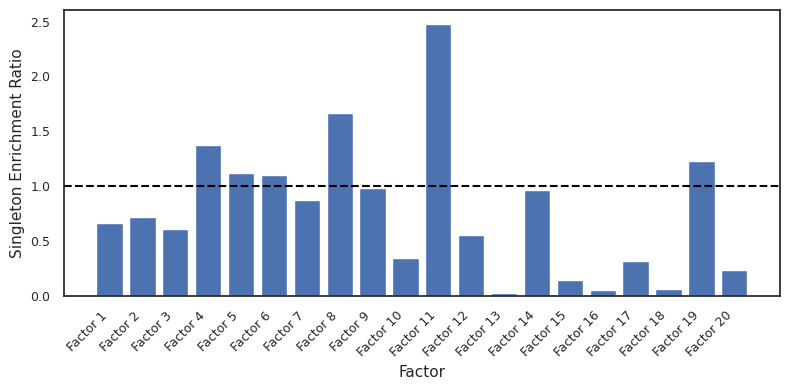

In [71]:
import matplotlib.pyplot as plt

# Compute enrichment dataframe (as you already have)
junction_counts = diff_spl["junction_idx"].value_counts()
singleton_junctions = junction_counts[junction_counts == 1].index
singleton_df = diff_spl[diff_spl["junction_idx"].isin(singleton_junctions)].copy()
singleton_counts_by_factor = singleton_df["factor_idx"].value_counts().sort_index()
all_counts_by_factor = diff_spl["factor_idx"].value_counts().sort_index()

enrichment_df = pd.DataFrame({
    "singleton_count": singleton_counts_by_factor,
    "all_count": all_counts_by_factor
}).fillna(0)

enrichment_df["fraction_singletons"] = enrichment_df["singleton_count"] / enrichment_df["singleton_count"].sum()
enrichment_df["fraction_all"] = enrichment_df["all_count"] / enrichment_df["all_count"].sum()
enrichment_df["enrichment"] = enrichment_df["fraction_singletons"] / enrichment_df["fraction_all"]

# Generate x-axis labels as Factor 1, Factor 2, ...
factor_labels = [f"Factor {i+1}" for i in enrichment_df.index]

# Plot
plt.figure(figsize=(8, 4))  # narrower width
plt.bar(factor_labels, enrichment_df["enrichment"])
plt.axhline(1.0, linestyle="--", color="black")
plt.xlabel("Factor")
plt.ylabel("Singleton Enrichment Ratio")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [72]:
# plot expression of MATR3 vs Factor 2 activity in top 10 cell types using separate curves for each cell types
filtered_splice_adata, filtered_ge_adata

(AnnData object with n_obs × n_vars = 147979 × 39656
     obs: 'cell_id_index', 'age', 'cell_ontology_class', 'donor_id', 'sex', 'subtissue', 'tissue', 'dataset', 'cell_name', 'cell_id', 'cell_clean', 'broad_cell_type', 'seqtech', 'AgingScore_unweighted', 'AgingScore_pos', 'AgingScore_neg', 'nuclear_ratio_log_norm', 'age_numeric', 'age_group', 'total_counts', 'nuclear_class_log_norm', 'nuclear_score_log_norm', 'cell_type_module', 'functional_category', 'tissue_system', 'lifespan_category', 'simple_category', 'senescence_proneness', 'Factor_1', 'Factor_2', 'Factor_3', 'Factor_4', 'Factor_5', 'Factor_6', 'Factor_7', 'Factor_8', 'Factor_9', 'Factor_10', 'Factor_11', 'Factor_12', 'Factor_13', 'Factor_14', 'Factor_15', 'Factor_16', 'Factor_17', 'Factor_18', 'Factor_19', 'Factor_20', 'perplexity'
     var: 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'junction_conserved',

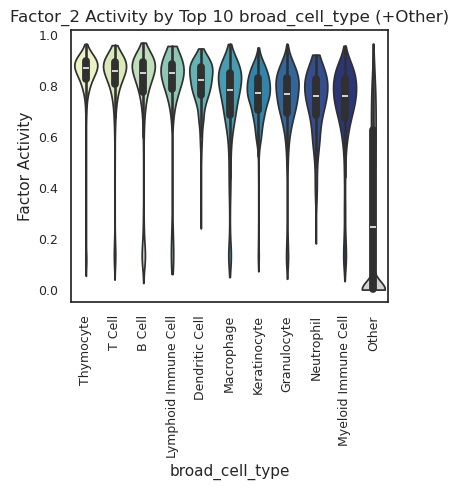

In [73]:
plot_factor_violin_sorted(
    adata=filtered_splice_adata,
    factor_list=["Factor_2"],
    groupby="broad_cell_type",
    top_n=10,
    cmap="YlGnBu",
    save_prefix="sorted_violin",
    width=4,
    height=5
)


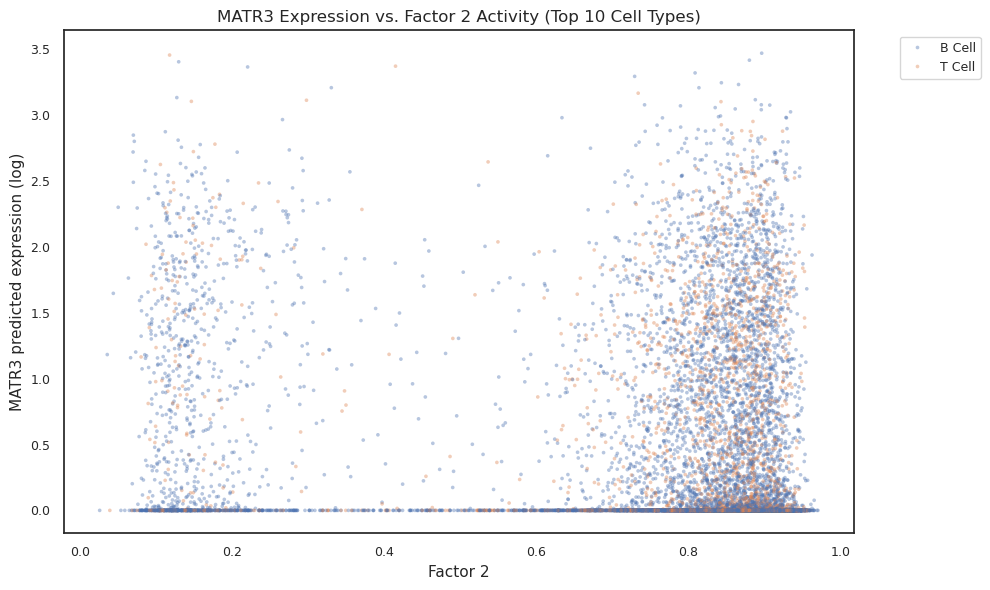

In [74]:
# Step 1: Extract MATR3 expression from the correct layer
gene = "MATR3"
if gene not in filtered_ge_adata.var["gene_name"].values:
    raise ValueError(f"{gene} not found in gene expression AnnData")

gene_idx = filtered_ge_adata.var.query("gene_name == @gene").index[0]
matr3_expr = filtered_ge_adata.layers["log_norm"][:, filtered_ge_adata.var_names.get_loc(gene_idx)].toarray().flatten()

# Step 2: Build a DataFrame with expression, factor activity, and cell type
df = pd.DataFrame({
    "MATR3_expression": matr3_expr,
    "Factor_2": filtered_splice_adata.obs.loc[:, "Factor_2"].values,
    "broad_cell_type": filtered_ge_adata.obs.loc[:, "broad_cell_type"].values
})

# Step 3: Select top 10 most common cell types
top_celltypes = ["B Cell", "T Cell"]
df_top = df[df["broad_cell_type"].isin(top_celltypes)]

# --- Step 1–3 already done ---

# Step 4: Scatter + smoothed trend line (per cell type)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_top,
    x="Factor_2",
    y="MATR3_expression",
    hue="broad_cell_type",
    alpha=0.4,
    s=7,
    linewidth=0
)

plt.title("MATR3 Expression vs. Factor 2 Activity (Top 10 Cell Types)")
plt.xlabel("Factor 2")
plt.ylabel("MATR3 predicted expression (log)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()